# Does the gateway-field retention signal replicate? (demo of `eval.py`)

Iteration 1 found one live lead: the **gateway (eigenvector) centrality** of the adopting field on a 26-field
1998-2002 PMI relatedness backbone (`gateway_j`) added **+0.103 AUC** to predicting **field retention R** (does field
*j* still publish on concept *c* 6-8 years after adopting it?). That lead came from one file (exp4: 80 episodes,
28 concepts). The original `eval.py` stress-tests it without any API calls, reading only iteration-1 outputs:

| block | question |
|---|---|
| **Step 0** | harmonise the files onto exp4's backbone and **reproduce** exp4's 0.10254 / 0.10222 exactly |
| **A** | leave-one-home-group-out (LOGO) logistic delta-AUC over richer baselines M0 → M1 → M2, with a concept-clustered **refit** bootstrap |
| **B** | trait confound: field propensity P (B1), field-intercept decomposition (B2), time-varying gateway (B3) |
| **C** | placebos: degree-preserving rewiring (C1), node-label permutation (C2), rival centralities with Holm correction (C3) |
| **D** | O1 label-coverage artefact re-screen |
| **E** | power / MDE (analytic + simulation, with a field random intercept) |
| **F** | corrected record tables (F5: refit CIs for exp4's field-level rows) |

The full run's verdict was **FAILS**: on the 362-episode union panel the gain over M2 is +0.001 [-0.012, 0.012],
and on the 282 new episodes it is -0.001.

**What this demo runs.** `mini_demo_data.json` holds the **exp4 panel itself** (80 episodes, the data behind the
original lead), the 26-field backbone, and the full run's headline numbers for comparison. The notebook runs Step 0,
A, B1/B2, C1-C3, E and F5 on that panel, using the original code with fewer bootstrap / permutation / simulation
draws (see the config cell). Blocks that need other iteration-1 files (exp1/exp3/union panels, B3's topic-pair
scan, D's concept-level O1 table) are not re-run. Their full-run results appear in the final comparison table.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, networkx, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'networkx==3.6.1', 'matplotlib==3.10.0')

## Imports and logging
The import block of `eval.py`, unchanged. The only edits: `HERE` is the notebook's working directory (a notebook
has no `__file__`), and `import harmonise as H` / `import lib` move below, after the cells that define them.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import multiprocessing as mp
import pickle
import resource
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import norm, spearmanr

# notebook additions
from types import SimpleNamespace
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()  # original: Path(__file__).resolve().parent
(HERE / "logs").mkdir(exist_ok=True)
(HERE / "results" / "cache").mkdir(parents=True, exist_ok=True)
(HERE / "figures").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(HERE / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

2

## Load the demo data
`mini_demo_data.json` is fetched from the GitHub repository, with a local-file fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-2/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
DEMO = data  # keep a handle: Step 0 below re-uses the name `data`, as eval.py does
print(DEMO["description"])
print(f"{len(DEMO['examples'])} episodes | {len({r['concept'] for r in DEMO['examples']})} concepts | "
      f"backbone: {len(DEMO['backbone']['fields'])} fields ({DEMO['backbone']['slice']}) | "
      f"propensity pool: {len(DEMO['propensity_pool']['rows'])} rows (exp4 + exp3 + exp1)")
pd.DataFrame(DEMO["examples"]).head()

exp4 (iteration-1) harmonised field-retention episodes on the 26-field 1998-2002 PMI backbone; one row = adoption episode (concept c, off-home field j), R = field still publishes on c 6-8 years later.
80 episodes | 28 concepts | backbone: 26 fields (1998-2002) | propensity pool: 576 rows (exp4 + exp3 + exp1)


,concept,group,key,dkey,source,R,t0,b_logn,b_growth,b_share,...,b5_reach,n_early,one_to_many,many_to_one,field_s2,density_j,home,exp4_file_gateway_j,exp4_file_phi_home_j,exp4_file_log_field_size
0,zinc finger nuclease,BGM,Medicine,Medicine,exp4,1.0,2005.0,1.945910,0.000000,0.117647,...,3,6.0,0,0,,0.112924,"[Biochemistry, Genetics and Molecular Biology]",0.299723,0.617836,14.928784
1,sentiment analysis,CS,Social Sciences,Social Sciences,exp4,1.0,2007.0,2.079442,-0.693147,0.159091,...,3,7.0,0,0,,0.061777,[Computer Science],0.028155,0.000000,15.210536
2,biosimilar,Med,"Biochemistry, Genetics and Molecular Biology","Biochemistry, Genetics and Molecular Biology",exp4,1.0,2006.0,2.397895,0.538997,0.092593,...,5,10.0,0,0,,0.105748,[Medicine],0.419023,0.617836,14.170420
3,smart grid,Eng,Social Sciences,Social Sciences,exp4,0.0,2008.0,4.394449,1.210404,0.122888,...,5,80.0,0,0,,0.614461,[Engineering],0.028155,0.485633,15.210536
4,smart grid,Eng,"Business, Management and Accounting","Business, Management and Accounting",exp4,0.0,2008.0,1.945910,0.000000,0.009217,...,5,6.0,0,0,,0.034674,[Engineering],0.077116,0.000000,13.021725


## Configuration
`eval.py` takes these values as command-line arguments. The demo values are small so that the whole notebook finishes
in a few minutes on a 2-CPU Colab runtime. The original values are in the comments. Point estimates (every
`delta`) do not depend on these numbers. Only the width of the CIs, placebo nulls and power simulations does.

In [5]:
N_WORKERS = 2          # original: 4 (spawn process pool; Colab has 2 CPUs)
SEED = 20260928        # original seed

args = SimpleNamespace(
    n_boot=2000,            # union / new-episodes panels (not in this demo)
    n_boot_secondary=2000,  # exp1 / exp3 panels (not in this demo)
    n_boot_exp4=400,        # original: 2000 -- Block A refit bootstrap draws on exp4
    n_boot_F5=500,          # original: 1000 -- F5 refit CIs of exp4's field-level rows
    n_boot_coef=1000,       # original: 1000 -- bootstrap of the standardised gateway coefficient
    n_perm=1000,            # original: 1000 -- C2 node-label permutations
    n_rewire=200,           # original: 200  -- C1 rewired backbones per variant
    n_perm_B2=2000,         # original: 2000 -- B2 stage-2 slope permutations
    n_sim=100,              # original: 500  -- Block E simulations per cell and condition
    n_sim_pilot=48,         # original: 48   -- Block E calibration pilot simulations per grid value
    use_cache=False,        # original flag --use-cache (reuse results/cache/*.pkl)
    blocks="ABCEF",         # original: "ABCDEF" (Block D needs exp4's concept-level O1 table, not in the demo)
)
E_PANEL = "exp4"       # original: Block E is sized on the "union" panel (not in this demo)

## Dependency 1: exp4's `screen.py` (iteration 1)
`lib.py` imports iteration-1 exp4's own `screen.py` read-only. It supplies the LOGO logistic model, training-fold
median imputation, AUC, DerSimonian-Laird pooling and exp4's field-level bootstrap. The cell writes it to disk,
**verbatim**, so the spawned worker processes can import it. Functions that `eval.py` never calls (`paired_delta`,
`loco_delta`, `single_indicator`, ...) are left out.

**LOGO** = leave one of the four home groups (CS, Eng, BGM, Med) out, fit on the other three, predict the held-out one.

In [6]:
%%writefile screen.py
"""Pre-registered S0 screen statistics: LOGO ridge/logistic, paired bootstrap deltas, per-group signs,
DerSimonian-Laird pooling, field-level clustered bootstrap."""
from __future__ import annotations

import math
import warnings

import numpy as np
import pandas as pd
from scipy.stats import norm, rankdata, spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
GROUPS = ["CS", "Eng", "BGM", "Med"]


def _prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Median-impute each column with the TRAINING-fold median (G's missing indicator is a separate column)."""
    X = X.copy()
    for c in X.columns:
        med = X.loc[train, c].median()
        X[c] = X[c].fillna(med if np.isfinite(med) else 0.0)
    return X.values.astype(float)


def logo_predict(df: pd.DataFrame, cols: list[str], y: str, kind: str = "ridge") -> np.ndarray:
    """Leave-one-home-group-out out-of-fold predictions."""
    oof = np.full(len(df), np.nan)
    g = df["group"].values
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        Xall = _prep(df[cols], tr)
        yt = df.loc[tr, y].values
        if kind == "ridge":
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            m.fit(Xall[tr], yt)
            oof[te] = m.predict(Xall[te])
        else:
            if len(np.unique(yt)) < 2:
                oof[te] = yt.mean()
                continue
            m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
            m.fit(Xall[tr], yt.astype(int))
            oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def _auc(y, p) -> float:
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4 or len(np.unique(y[ok])) < 2:
        return math.nan
    return float(roc_auc_score(y[ok].astype(int), p[ok]))


# ------------------------------------------------------------------ meta-analysis
def dersimonian_laird(est: list[float], var: list[float]) -> dict:
    e = np.array(est, float)
    v = np.array(var, float)
    ok = np.isfinite(e) & np.isfinite(v) & (v > 0)
    e, v = e[ok], v[ok]
    k = len(e)
    if k < 2:
        return {"k": k, "pooled": float(e[0]) if k else math.nan, "se": math.nan, "tau2": math.nan, "I2": math.nan}
    w = 1 / v
    fe = (w * e).sum() / w.sum()
    Q = (w * (e - fe) ** 2).sum()
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0
    ws = 1 / (v + tau2)
    re = (ws * e).sum() / ws.sum()
    se = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 else 0.0
    return {"k": k, "pooled": float(re), "se": float(se), "tau2": float(tau2), "I2": float(I2), "Q": float(Q)}


# ------------------------------------------------------------------ field level
def field_level(fr: pd.DataFrame, base: list[str], cand: list[str], n_boot: int = 2000, seed: int = 1) -> dict:
    d = fr.dropna(subset=["R"]).reset_index(drop=True)
    ob = logo_predict(d, base, "R", "logit")
    oc = logo_predict(d, cand, "R", "logit")
    Y = d["R"].values.astype(float)
    ab, ac = _auc(Y, ob), _auc(Y, oc)
    rng = np.random.default_rng(seed)
    cons = d["concept"].unique()
    rows = {c: np.where(d["concept"].values == c)[0] for c in cons}
    boots = []
    for _ in range(n_boot):
        pick = rng.choice(cons, len(cons))
        i = np.concatenate([rows[c] for c in pick])
        a, b = _auc(Y[i], ob[i]), _auc(Y[i], oc[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        per[g] = {"n_rows": int(m.sum()), "base": _auc(Y[m], ob[m]), "cand": _auc(Y[m], oc[m])}
    return {"n_rows": len(d), "n_concepts": len(cons), "prevalence": float(Y.mean()), "auc_base": ab, "auc_cand": ac,
            "delta_auc": ac - ab, "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))],
            "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))], "per_group": per}

Overwriting screen.py


## Dependency 2: `lib.py`, the core statistics
The evaluation's own `lib.py`, also written to disk so the spawn workers can import it. Changes: `screen` is imported
from the file above, not from the iteration-1 folder, and the Block D functions (`o1_base`, `logo_concept`,
`concept_specs_eval`, `concept_boot_worker`) are left out because Block D is not run here.

Contents:
* `fast_prep` / `fast_auc`: numerically identical numpy versions of `screen._prep` / `screen._auc`. Step 0 checks the equivalence.
* `propensity` / `logo_ext`: the **field propensity P** (leave-concept-out, shrunken field retention mean), recomputed inside every training fold so it cannot leak.
* `eval_specs`: fits each distinct feature set once and returns the pooled and per-group delta-AUC for every (base, candidate) spec.
* `resample` / `boot_worker`: the **concept-clustered refit bootstrap**. Each draw resamples concepts and refits every LOGO model.
* `perm_worker`: placebo gateway vectors (rewired or permuted) in place of `gateway_j`.
* `sim_worker`: Block E power simulations.

In [7]:
%%writefile lib.py
"""Core statistics for the gateway stress test. Worker-safe (imported by spawn workers): no logging side effects.

The LOGO logistic model, training-fold median imputation and AUC come from iteration-1 exp4's screen.py, imported
read-only (never rewritten). The only extension is fold-dependent columns (field propensity P, O1_base) that must be
recomputed inside each training fold to stay leakage-free.
"""
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Notebook: screen.py is written next to this file by the previous cell (original: sys.path.insert of the
# iteration-1 folder gen_art_experiment_4, which holds exp4's screen.py).
import screen as S4  # noqa: E402  exp4's own screen.py (logo_predict, _prep, _auc, dersimonian_laird)

GROUPS = S4.GROUPS  # ["CS", "Eng", "BGM", "Med"]
_ORIG_PREP, _ORIG_AUC = S4._prep, S4._auc


def fast_prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Numerically identical numpy version of screen._prep (training-fold median imputation per column)."""
    A = X.to_numpy(dtype=float, copy=True)
    if np.isnan(A).any():
        with np.errstate(all="ignore"):
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                med = np.nanmedian(A[train], axis=0)
        med = np.where(np.isfinite(med), med, 0.0)
        r, c = np.nonzero(np.isnan(A))
        A[r, c] = med[c]
    return A


def fast_auc(y, p) -> float:
    """Rank (Mann-Whitney) AUC with screen._auc's conventions (finite rows, >= 4 rows, both classes)."""
    from scipy.stats import rankdata
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4:
        return math.nan
    y, p = y[ok], p[ok]
    n1 = y.sum()
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return math.nan
    r = rankdata(p)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


# Speed: exp4's logo_predict looks up _prep at call time; the numpy version gives identical matrices (verified in
# eval.py against the original on every dataset before use).
S4._prep = fast_prep


# ----------------------------------------------------------------------------- fold-dependent features
def propensity(key: np.ndarray, cl: np.ndarray, y: np.ndarray, grp: np.ndarray, test_g: str, a: float,
               pool: pd.DataFrame | None = None, concept: np.ndarray | None = None) -> np.ndarray:
    """Shrunken leave-concept-out field retention propensity for one LOGO fold.

    Within-dataset (pool None): statistics from training-fold rows (group != test_g) of the same field key;
    test rows use all training rows of the key, training rows exclude rows of their own cluster (concept copy).
    Pooled: statistics from the external pool (rows of all three files) with group != test_g and concept != own
    concept, for both test and training rows. P = (sum R + a*pbar) / (n + a); pbar = training mean; n=0,a=0 -> pbar.
    """
    n = len(y)
    out = np.empty(n)
    if pool is None:
        tr = grp != test_g
        pbar = float(y[tr].mean())
        d = pd.DataFrame({"k": key[tr], "c": cl[tr], "y": y[tr]})
        tot = d.groupby("k")["y"].agg(["sum", "count"])
        byc = d.groupby(["k", "c"])["y"].agg(["sum", "count"])
        ks = tot.reindex(key)
        s_all = np.nan_to_num(ks["sum"].to_numpy(float))
        n_all = np.nan_to_num(ks["count"].to_numpy(float))
        own = byc.reindex(pd.MultiIndex.from_arrays([key, cl]))
        s_own = np.nan_to_num(own["sum"].to_numpy(float))
        n_own = np.nan_to_num(own["count"].to_numpy(float))
        s = np.where(tr, s_all - s_own, s_all)
        c = np.where(tr, n_all - n_own, n_all)
    else:
        pp = pool[pool["group"].to_numpy() != test_g]
        pbar = float(pp["R"].mean())
        tot = pp.groupby("key")["R"].agg(["sum", "count"])
        byc = pp.groupby(["key", "concept"])["R"].agg(["sum", "count"])
        ks = tot.reindex(key)
        own = byc.reindex(pd.MultiIndex.from_arrays([key, concept]))
        s = np.nan_to_num(ks["sum"].to_numpy(float)) - np.nan_to_num(own["sum"].to_numpy(float))
        c = np.nan_to_num(ks["count"].to_numpy(float)) - np.nan_to_num(own["count"].to_numpy(float))
    den = c + a
    out[:] = np.where(den > 0, (s + a * pbar) / np.where(den > 0, den, 1.0), pbar)
    return out


def logo_ext(df: pd.DataFrame, cols: list[str], y: str = "R", a: float = 2.0, pool: pd.DataFrame | None = None,
             cl_col: str = "cl") -> np.ndarray:
    """exp4 screen.logo_predict(kind='logit') plus fold-computed P columns ('P_within', 'P_pooled')."""
    dyn = [c for c in cols if c in ("P_within", "P_pooled")]
    if not dyn:
        return S4.logo_predict(df, cols, y, "logit")
    oof = np.full(len(df), np.nan)
    g = df["group"].to_numpy()
    Y = df[y].to_numpy(float)
    key = df["key"].to_numpy()
    cl = df[cl_col].to_numpy()
    con = df["concept"].to_numpy()
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        X = df[[c for c in cols if c not in dyn]].copy()
        if "P_within" in dyn:
            X["P_within"] = propensity(key, cl, Y, g, lg, a)
        if "P_pooled" in dyn:
            X["P_pooled"] = propensity(key, cl, Y, g, lg, a, pool=pool, concept=con)
        X = X[cols]
        Xall = S4._prep(X, tr)
        yt = Y[tr]
        if len(np.unique(yt)) < 2:
            oof[te] = yt.mean()
            continue
        m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
        m.fit(Xall[tr], yt.astype(int))
        oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def pooled_auc(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> tuple[float, int]:
    """Pooled OOF AUC after dropping rows of test groups that contain a single class. Returns (auc, n_dropped_groups)."""
    keep = np.ones(len(y), bool)
    nd = 0
    for lg in GROUPS:
        m = g == lg
        if m.sum() and len(np.unique(y[m])) < 2:
            keep &= ~m
            nd += 1
    return fast_auc(y[keep], p[keep]), nd


def group_aucs(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> dict:
    return {lg: fast_auc(y[g == lg], p[g == lg]) for lg in GROUPS}


def eval_specs(df: pd.DataFrame, specs: list[tuple[str, list[str], list[str]]], a: float = 2.0,
               pool: pd.DataFrame | None = None, keep_oof: bool = False) -> dict:
    """Fit every distinct model once; return pooled/per-group delta-AUC per spec."""
    cache: dict[tuple, np.ndarray] = {}
    Y = df["R"].to_numpy(float)
    g = df["group"].to_numpy()

    def get(cols):
        k = tuple(cols)
        if k not in cache:
            cache[k] = logo_ext(df, list(cols), "R", a, pool)
        return cache[k]
    out = {}
    for name, base, cand in specs:
        ob, oc = get(base), get(cand)
        ab, nd = pooled_auc(Y, ob, g)
        ac, _ = pooled_auc(Y, oc, g)
        gb, gc = group_aucs(Y, ob, g), group_aucs(Y, oc, g)
        r = {"auc_base": ab, "auc_cand": ac, "delta": ac - ab, "n_groups_dropped": nd,
             "per_group": {lg: {"base": gb[lg], "cand": gc[lg],
                                "delta": (gc[lg] - gb[lg]) if np.isfinite(gb[lg]) and np.isfinite(gc[lg]) else math.nan}
                           for lg in GROUPS},
             "brier_base": float(np.nanmean((ob - Y) ** 2)), "brier_cand": float(np.nanmean((oc - Y) ** 2))}
        if keep_oof:
            r["oof_base"], r["oof_cand"] = ob, oc
        out[name] = r
    return out


def resample(df: pd.DataFrame, rng: np.random.Generator, stratified: bool = False) -> pd.DataFrame:
    """Concept-clustered resample; every duplicated concept gets a fresh cluster id ('cl')."""
    cons = df["concept"].unique()
    rows = {c: np.flatnonzero(df["concept"].to_numpy() == c) for c in cons}
    if stratified:
        cg = df.groupby("concept")["group"].first()
        pick = np.concatenate([rng.choice(cg.index[cg == lg].to_numpy(), (cg == lg).sum())
                               for lg in GROUPS if (cg == lg).sum()])
    else:
        pick = rng.choice(cons, len(cons))
    idx, cid = [], []
    for k, c in enumerate(pick):
        idx.append(rows[c])
        cid.append(np.full(len(rows[c]), k))
    d = df.iloc[np.concatenate(idx)].reset_index(drop=True)
    d["cl"] = np.concatenate(cid)
    return d


def boot_worker(args: tuple) -> list[dict]:
    """One chunk of refit bootstrap draws. args = (df, specs, seeds, a, pool, stratified)."""
    df, specs, seeds, a, pool, stratified = args
    res = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        d = resample(df, rng, stratified)
        r = eval_specs(d, specs, a, pool)
        res.append({k: {"delta": v["delta"], "nd": v["n_groups_dropped"],
                        "pg": {lg: v["per_group"][lg]["delta"] for lg in GROUPS}} for k, v in r.items()})
    return res


def perm_worker(args: tuple) -> list[dict]:
    """Placebo gateway vectors: args = (df, W, base_cols, gvecs, a). Returns point delta-AUC per vector for each base."""
    df, W, bases, gvecs = args
    Y = df["R"].to_numpy(float)
    g = df["group"].to_numpy()
    base_auc = {nm: pooled_auc(Y, S4.logo_predict(df, cols, "R", "logit"), g)[0] for nm, cols in bases.items()}
    out = []
    for gv in gvecs:
        d = df.copy()
        d["g_plac"] = W @ gv
        r = {}
        for nm, cols in bases.items():
            r[nm] = pooled_auc(Y, S4.logo_predict(d, cols + ["g_plac"], "R", "logit"), g)[0] - base_auc[nm]
        out.append(r)
    return out


# ----------------------------------------------------------------------------- Block E simulation
def sim_worker(args: tuple) -> list[float]:
    """Simulate clustered episodes from the fitted M2+gateway model and return sampling draws of 4-fold grouped-CV
    delta-AUC. args = (Xpool, beta0, beta, gcol, sigma_c, N, m, seeds)."""
    from sklearn.model_selection import GroupKFold
    Xpool, b0, beta, gcol, sig, N, m, seeds = args[:8]
    keyc, tau_f = (args[8], args[9]) if len(args) > 8 else (None, 0.0)
    out = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        nc = int(math.ceil(N / m))
        idx = rng.integers(0, len(Xpool), nc * m)
        X = Xpool[idx]
        conc = np.repeat(np.arange(nc), m)
        u = rng.normal(0, sig, nc)[conc]
        eta = b0 + X @ beta + u
        if keyc is not None and tau_f > 0:  # field random intercept: arbitrary field constants can absorb it
            eta = eta + rng.normal(0, tau_f, int(keyc.max()) + 1)[keyc[idx]]
        y = rng.random(len(eta)) < 1 / (1 + np.exp(-eta))
        if y.all() or (~y).all():
            continue
        pb = np.full(len(y), np.nan)
        pc = np.full(len(y), np.nan)
        base_cols = [i for i in range(X.shape[1]) if i != gcol]
        for tr, te in GroupKFold(4).split(X, y, conc):
            if len(np.unique(y[tr])) < 2:
                continue
            for cols, dest in ((base_cols, pb), (list(range(X.shape[1])), pc)):
                mdl = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
                mdl.fit(X[tr][:, cols], y[tr])
                dest[te] = mdl.predict_proba(X[te][:, cols])[:, 1]
        out.append(fast_auc(y.astype(float), pc) - fast_auc(y.astype(float), pb))
    return out

Overwriting lib.py


In [8]:
if str(HERE) not in sys.path:  # notebook: make screen.py / lib.py importable here and in the spawn workers
    sys.path.insert(0, str(HERE))
import lib  # noqa: E402
from lib import GROUPS, S4  # noqa: E402
print("groups:", GROUPS, "| screen._prep patched to lib.fast_prep:", S4._prep is lib.fast_prep)

groups: ['CS', 'Eng', 'BGM', 'Med'] | screen._prep patched to lib.fast_prep: True


## Step 0 code: `harmonise.py`, exp4 part
`harmonise.py` attaches every file's episodes to exp4's 26-field backbone. Each episode gets a weight row `W` over
the 26 fields (one-hot for exp4), so any field-level vector `v` becomes an episode feature `W @ v`. That covers
`gateway_j`, the rival centralities, `log_field_size`, and relatedness to the home field(s) `phi_home_j`.

Feature families used below:
* `M0` = the dataset's own field baseline: early log count, growth, share (`b_logn`, `b_growth`, `b_share`)
* `B5` = concept-level spread baseline (`b5_logvol`, `b5_growth`, `b5_offhome`, `b5_entropy`, `b5_reach`)
* `REL` = `log_field_size`, `phi_home_j`, `density_j`

Code changes: `Backbone` reads `DEMO["backbone"]` rather than `field_backbone.json`. `load_exp4` reads
`DEMO["examples"]` rather than joining exp4's `field_outcomes.csv` and `features.csv`. `build_all` returns only the
exp4 panel plus the propensity pool (rows of all three files, stored in the JSON). `load_exp1`/`load_exp3` and the
union/overlap logic are not included. Everything else is copied as-is.

In [9]:
import networkx as nx

XW: dict = {}  # prereg/crosswalk.json (S2 -> OpenAlex field map) -- only needed for exp1, not in this demo
M0 = ["b_logn", "b_growth", "b_share"]
B5 = ["b5_logvol", "b5_growth", "b5_offhome", "b5_entropy", "b5_reach"]
REL = ["log_field_size", "phi_home_j", "density_j"]
RIVALS = ["r_strength", "r_degree", "r_betweenness", "r_pagerank", "r_closeness", "r_kcore", "r_eig_phimin",
          "log_field_size"]


class Backbone:
    def __init__(self) -> None:
        b = DEMO["backbone"]  # original: json.loads((E4 / "field_backbone.json").read_text())
        self.raw = b
        self.fields = b["fields"]
        self.idx = {f: i for i, f in enumerate(self.fields)}
        self.phi = np.array(b["phi"])
        self.phi_min = np.array(b["phi_min"])
        self.n = np.array(b["n_field"], float)
        self.logn = np.log(self.n)
        self.gate = np.array(b["gateway_eig"])
        self.domain = b["domain"]
        self.rivals = self._rivals()

    def graph(self) -> nx.Graph:
        G = nx.Graph()
        G.add_nodes_from(range(26))
        for i in range(26):
            for j in range(i + 1, 26):
                if self.phi[i, j] > 0:
                    G.add_edge(i, j, weight=self.phi[i, j], dist=1.0 / self.phi[i, j])
        return G

    def _rivals(self) -> dict[str, np.ndarray]:
        G = self.graph()
        v = lambda d: np.array([d[i] for i in range(26)], float)  # noqa: E731
        return {"gateway_j": self.gate,
                "r_strength": v(dict(G.degree(weight="weight"))),
                "r_degree": v(dict(G.degree())),
                "r_betweenness": v(nx.betweenness_centrality(G, weight="dist")),
                "r_pagerank": v(nx.pagerank(G, alpha=0.85, weight="weight")),
                "r_closeness": v(nx.closeness_centrality(G, distance="dist")),
                "r_kcore": v(nx.core_number(G)),
                "r_eig_phimin": np.array(self.raw["gateway_eig_phimin"]),
                "log_field_size": self.logn}


def _w_row(bb: Backbone, names: list[str]) -> np.ndarray:
    w = np.zeros(26)
    ii = [bb.idx[n] for n in names]
    w[ii] = bb.n[ii] / bb.n[ii].sum()
    return w


def _attach(df: pd.DataFrame, W: np.ndarray, homes: list[list[int]], bb: Backbone, K: list[set[int]] | None) -> None:
    """gateway, rivals, log_field_size, phi_home_j and (if K given) density_j from weight rows W."""
    for nm, vec in bb.rivals.items():
        df[nm] = W @ vec
    df["phi_home_j"] = [float(np.mean([bb.phi[h] @ w for h in hs])) if hs else 0.0 for w, hs in zip(W, homes)]
    if K is not None:
        dens = []
        colsum = bb.phi.sum(0)
        for w, Kc in zip(W, K):
            val = 0.0
            for k in np.flatnonzero(w):
                Kj = list(Kc - {k})
                val += w[k] * (bb.phi[Kj, k].sum() / colsum[k] if Kj and colsum[k] > 0 else 0.0)
            dens.append(val)
        df["density_j"] = dens


def _K_from_rows(df: pd.DataFrame, W: np.ndarray, homes: list[list[int]]) -> list[set[int]]:
    """Early-window field presence approximated by the concept's home field(s) plus every field with a retention row
    (rows require >= 5 early papers; exp4's own rule is >= 2 labelled papers, which the exp1/exp3 files do not hold)."""
    pres: dict[str, set[int]] = {}
    for c, w, hs in zip(df["concept"], W, homes):
        pres.setdefault(c, set(hs)).update(np.flatnonzero(w).tolist())
    return [pres[c] for c in df["concept"]]


def load_exp4(bb: Backbone) -> tuple[pd.DataFrame, np.ndarray, dict]:
    # original: fr = field_outcomes.csv merged with features.csv; the demo JSON stores the merged, renamed rows
    d = pd.DataFrame(DEMO["examples"])
    W = np.vstack([_w_row(bb, [f]) for f in d["key"]])
    homes = [[bb.idx[h] for h in hs if h in bb.idx] for hs in d["home"]]
    orig = pd.DataFrame({"gateway_j": d["exp4_file_gateway_j"], "phi_home_j": d["exp4_file_phi_home_j"],
                         "log_field_size": d["exp4_file_log_field_size"], "density_j": d["density_j"]})
    out = d[["concept", "group", "key", "dkey", "source", "R", "t0", "b_logn", "b_growth", "b_share", "b5_logvol",
             "b5_growth", "b5_offhome", "b5_entropy", "b5_reach", "n_early", "one_to_many", "many_to_one",
             "field_s2"]].copy()
    out["R"] = out["R"].astype(float)
    _attach(out, W, homes, bb, None)
    Kapprox = _K_from_rows(out, W, homes)
    tmp = out.copy()
    _attach(tmp, W, homes, bb, Kapprox)
    chk = {"gateway_j_maxabs": float(np.abs(out["gateway_j"] - orig["gateway_j"]).max()),
           "phi_home_j_maxabs": float(np.abs(out["phi_home_j"] - orig["phi_home_j"]).max()),
           "log_field_size_maxabs": float(np.abs(out["log_field_size"] - orig["log_field_size"]).max()),
           "density_j_rows_approx_vs_exp4": {"spearman": float(pd.Series(tmp["density_j"]).corr(orig["density_j"],
                                                                                                method="spearman")),
                                             "maxabs": float(np.abs(tmp["density_j"] - orig["density_j"]).max())}}
    out["density_j"] = orig["density_j"].to_numpy()  # exp4's own K (>=2 labelled papers in t0..t0+2) is authoritative
    return out, W, chk


def build_all() -> dict:
    bb = Backbone()
    d4, W4, c4 = load_exp4(bb)
    for d in (d4,):  # original: (d4, d1, d3)
        d["cl"] = d["concept"]
    # pooled pool for P_pooled: every row of all three files (exp4 80 + exp3 129 + exp1 367 rows, stored in the JSON)
    pp = DEMO["propensity_pool"]
    pool = pd.DataFrame(pp["rows"], columns=pp["columns"])
    return {"bb": bb, "exp4": (d4, W4), "pool": pool, "checks": {"exp4_recompute": c4}}


H = SimpleNamespace(M0=M0, B5=B5, REL=REL, RIVALS=RIVALS, XW=XW, Backbone=Backbone, build_all=build_all)

## `eval.py` helpers: caching, process pool, CI summary, Holm correction
Copied unchanged, except that `N_WORKERS` and `SEED` come from the config cell. `pool_map` keeps the original
spawn-context `ProcessPoolExecutor`. The worker functions live in `lib.py` on disk, so the spawned processes can
import them.

In [10]:
RES = HERE / "results"
CACHE = RES / "cache"


def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def cached(name: str, fn, use: bool):
    p = CACHE / f"{name}.pkl"
    if use and p.exists():
        logger.info(f"[cache] {name}")
        return pickle.loads(p.read_bytes())
    t = time.time()
    r = fn()
    p.write_bytes(pickle.dumps(r))
    logger.info(f"{name} done in {time.time() - t:.0f}s")
    return r


_EXEC: ProcessPoolExecutor | None = None


def pool_map(fn, jobs: list) -> list:
    """Map over one shared spawn-context process pool (created once to avoid repeated spawn/import cost)."""
    global _EXEC
    if _EXEC is None:
        _EXEC = ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=mp.get_context("spawn"))
    return list(_EXEC.map(fn, jobs))


def chunks(seeds: list[int], k: int) -> list[list[int]]:
    return [list(x) for x in np.array_split(np.array(seeds), k) if len(x)]


def ci(x: np.ndarray) -> dict:
    x = np.asarray([v for v in x if np.isfinite(v)])
    if not len(x):
        return {"n": 0}
    return {"n": int(len(x)), "sd": float(x.std(ddof=1)), "ci90": [float(np.percentile(x, 5)), float(np.percentile(x, 95))],
            "ci95": [float(np.percentile(x, 2.5)), float(np.percentile(x, 97.5))],
            "p_le0": float(np.mean(x <= 0)), "p_two_sided": float(min(1.0, 2 * min(np.mean(x <= 0), np.mean(x >= 0))))}


def holm(ps: dict[str, float]) -> dict[str, float]:
    items = sorted(ps.items(), key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out

## Spec sets and the refit bootstrap
Each spec is a triple `(name, base features, base features + candidate)`. The nested baselines are **M0** (field
baseline), **M1** = M0 + B5, and **M2** = M1 + REL. `gateway_j` is added on top of each. `M2+P` asks whether gateway
still adds anything once the field's own retention propensity P is known (B1). `P_alone` asks whether P by itself
carries the gain. `rival:*` swaps gateway for another centrality (C3).

`run_boot` spreads the refit bootstrap over the worker pool. `summarise_boot` turns the draws into percentile CIs
and per-group deltas.

In [11]:
# ----------------------------------------------------------------------------- spec sets
def spec_set(ds: str, rivals: bool) -> tuple[list, dict]:
    M0 = H.M0 + (["src_exp1", "src_exp3"] if ds in ("union", "union_agree", "new_eps") else [])
    M1 = M0 + H.B5
    M2 = M1 + H.REL + (["bg_LOR_j"] if ds.startswith("exp1") else [])
    g = "gateway_j"
    sp = [("M0", M0, M0 + [g]), ("M1", M1, M1 + [g]), ("M2", M2, M2 + [g]),
          ("M2+P", M2 + ["P_within"], M2 + ["P_within", g]), ("P_alone", M2, M2 + ["P_within"]),
          ("M2+Ppool", M2 + ["P_pooled"], M2 + ["P_pooled", g]), ("Ppool_alone", M2, M2 + ["P_pooled"])]
    if rivals:
        sp += [(f"rival:{r}", M2, M2 + [r]) for r in H.RIVALS if r != "log_field_size"]
        # log_field_size is already inside M2 -> its rival test is M2 without it vs M2
        m2ns = [c for c in M2 if c != "log_field_size"]
        sp += [("rival:log_field_size", m2ns, M2), ("gateway_vs_M2_minus_size", m2ns, m2ns + [g])]
    return sp, {"M0": M0, "M1": M1, "M2": M2}


def run_boot(df: pd.DataFrame, specs: list, n: int, pool: pd.DataFrame, seed: int, stratified: bool = False) -> list:
    seeds = list(range(seed, seed + n))
    jobs = [(df, specs, c, 2.0, pool, stratified) for c in chunks(seeds, N_WORKERS * 4)]
    out = []
    for r in pool_map(lib.boot_worker, jobs):
        out.extend(r)
    return out


def summarise_boot(point: dict, boots: list, specs: list) -> dict:
    res = {}
    for nm, _, _ in specs:
        arr = np.array([b[nm]["delta"] for b in boots], float)
        nd = int(sum(b[nm]["nd"] > 0 for b in boots))
        pg = {lg: ci(np.array([b[nm]["pg"][lg] for b in boots], float)) for lg in GROUPS}
        p = point[nm]
        res[nm] = {"auc_base": p["auc_base"], "auc_cand": p["auc_cand"], "delta": p["delta"],
                   "brier_change": p["brier_cand"] - p["brier_base"],
                   "refit_boot": {**ci(arr), "n_draws": len(boots), "draws_with_single_class_test_group": nd,
                                  "share_single_class_draws": nd / max(1, len(boots))},
                   "per_group": {lg: {**p["per_group"][lg], "boot": pg[lg]} for lg in GROUPS},
                   "n_groups_positive": int(sum(1 for lg in GROUPS if np.isfinite(p["per_group"][lg]["delta"])
                                                and p["per_group"][lg]["delta"] > 0)),
                   "n_groups_evaluable": int(sum(1 for lg in GROUPS if np.isfinite(p["per_group"][lg]["delta"])))}
    return res


def std_coef_boot(df: pd.DataFrame, cols: list[str], target: str, n: int, seed: int) -> dict:
    """Standardised logistic coefficient of `target` in a full-sample fit, concept-clustered bootstrap CI."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    def fit(d):
        X = S4._prep(d[cols], np.ones(len(d), bool))
        X = StandardScaler().fit_transform(X)
        y = d["R"].to_numpy(int)
        if len(np.unique(y)) < 2:
            return math.nan
        return float(LogisticRegression(C=1.0, max_iter=1000).fit(X, y).coef_[0][cols.index(target)])
    b0 = fit(df)
    rng = np.random.default_rng(seed)
    bs = [fit(lib.resample(df, rng)) for _ in range(n)]
    return {"coef_std": b0, **ci(np.array(bs))}

## Block B2 helpers: field intercepts and variance components
* `field_effects`: a stage-1 logistic fit of R on M1 plus one dummy per field. The dummy coefficients `u_j` are the field intercepts.
* `wls_perm`: a stage-2 WLS of `u_j` on `gateway_j`, weighted by the field's row count, with a permutation p-value. The question is whether gateway explains *which fields* retain.
* `mixed_icc`: latent-scale variance components from a Bayesian mixed logit, with field and/or concept random intercepts.

`slice_gateways` (B3, time-varying backbone) is left out because it needs exp3's topic-pair scan (`ckpt.npz`).

In [12]:
# ----------------------------------------------------------------------------- Block B2 / B3 helpers
def field_effects(df: pd.DataFrame, M1: list[str]) -> pd.DataFrame:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    X = StandardScaler().fit_transform(S4._prep(df[M1], np.ones(len(df), bool)))
    keys = sorted(df["key"].unique())
    D = (df["key"].to_numpy()[:, None] == np.array(keys)[None, :]).astype(float)
    m = LogisticRegression(C=1.0, max_iter=2000).fit(np.hstack([X, D]), df["R"].to_numpy(int))
    u = m.coef_[0][X.shape[1]:]
    cnt = df["key"].value_counts()
    return pd.DataFrame({"key": keys, "u": u, "n": [int(cnt[k]) for k in keys],
                         "gateway_j": [float(df.loc[df["key"] == k, "gateway_j"].iloc[0]) for k in keys],
                         "log_field_size": [float(df.loc[df["key"] == k, "log_field_size"].iloc[0]) for k in keys]})


def wls_perm(fe: pd.DataFrame, xcol: str, n_perm: int, seed: int) -> dict:
    import statsmodels.api as sm
    f = fe[fe["n"] >= 3].reset_index(drop=True)
    if len(f) < 4:
        return {"n_fields": int(len(f)), "note": "fewer than 4 fields with >= 3 rows"}
    X = sm.add_constant(f[xcol].to_numpy(float))
    r = sm.WLS(f["u"].to_numpy(float), X, weights=f["n"].to_numpy(float)).fit()
    slope = float(r.params[1])
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        xp = rng.permutation(f[xcol].to_numpy(float))
        null.append(sm.WLS(f["u"].to_numpy(float), sm.add_constant(xp), weights=f["n"].to_numpy(float)).fit().params[1])
    null = np.abs(np.array(null))
    return {"n_fields": int(len(f)), "slope": slope, "slope_se": float(r.bse[1]), "R2": float(r.rsquared),
            "perm_p_two_sided": float((1 + np.sum(null >= abs(slope))) / (1 + n_perm)), "n_perm": n_perm}


def mixed_icc(df: pd.DataFrame, fixed: list[str], vcs: list[str]) -> dict:
    """Latent-scale variance components from statsmodels BinomialBayesMixedGLM (variational Bayes)."""
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    from sklearn.preprocessing import StandardScaler
    d = df.copy()
    X = StandardScaler().fit_transform(S4._prep(d[fixed], np.ones(len(d), bool)))
    for i, c in enumerate(fixed):
        d[f"x{i}"] = X[:, i]
    d["concept_id"] = pd.factorize(d["concept"])[0]
    d["key_id"] = pd.factorize(d["key"])[0]
    fml = "R ~ " + " + ".join(f"x{i}" for i in range(len(fixed)))
    vc = {v: f"0 + C({v}_id)" for v in vcs}
    try:
        m = BinomialBayesMixedGLM.from_formula(fml, {k: vc[k] for k in vcs}, d.rename(columns={}), vcp_p=2.0)
        r = m.fit_vb()
    except (ValueError, np.linalg.LinAlgError) as e:
        logger.error(f"mixed GLM failed: {e}")
        return {"error": str(e)}
    sds = np.exp(r.vcp_mean)
    out = {f"tau2_{n}": float(s ** 2) for n, s in zip(m.vcp_names, sds)}
    tot = sum(out.values()) + math.pi ** 2 / 3
    for k in list(out):
        out[f"icc_latent_{k[5:]}"] = out[k] / tot
    return out

## Block C1 helpers: degree- and connectivity-preserving rewiring
The C1 placebo rewires the 26-field backbone with double-edge swaps that keep every node's degree and keep the graph
connected, then recomputes eigenvector centrality. If `gateway_j`'s gain were only a degree effect, rewired
"gateways" would do as well as the real one.

In [13]:
# ----------------------------------------------------------------------------- C1 rewiring
def _connected(E: dict, n: int = 26) -> bool:
    adj: dict[int, list[int]] = {i: [] for i in range(n)}
    for a, b in E:
        adj[a].append(b)
        adj[b].append(a)
    seen, stack = {0}, [0]
    while stack:
        for v in adj[stack.pop()]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == n


def rewire(edges: dict, rng: np.random.Generator, nswap: int, shuffle_w: bool) -> dict:
    """Degree- and connectivity-preserving double-edge swaps with weights carried by their edges."""
    E = dict(edges)
    keys = list(E)
    done, tries = 0, 0
    while done < nswap and tries < nswap * 50:
        tries += 1
        i1, i2 = rng.choice(len(keys), 2, replace=False)
        (u, v), (x, y) = keys[i1], keys[i2]
        if rng.random() < 0.5:
            x, y = y, x
        if len({u, v, x, y}) < 4:
            continue
        e1, e2 = tuple(sorted((u, x))), tuple(sorted((v, y)))
        if e1 in E or e2 in E:
            continue
        w1, w2 = E.pop(keys[i1]), E.pop(keys[i2])
        E[e1], E[e2] = w1, w2
        if not _connected(E):
            del E[e1], E[e2]
            E[keys[i1]], E[keys[i2]] = w1, w2
            continue
        keys = list(E)
        done += 1
    if shuffle_w:
        ws = rng.permutation(list(E.values()))
        E = dict(zip(E.keys(), ws))
    return E


def eig_from_edges(E: dict) -> np.ndarray:
    import networkx as nx
    G = nx.Graph()
    G.add_nodes_from(range(26))
    for (a, b), w in E.items():
        G.add_edge(a, b, weight=w)
    e = nx.eigenvector_centrality_numpy(G, weight="weight")
    v = np.abs(np.array([e[i] for i in range(26)]))
    return v / v.max()

## Figure function
`figures()` is copied unchanged. It writes a forest plot of delta-AUC over M2, the placebo histograms, the stage-2
field-intercept scatter, and the MDE-vs-N curve into `figures/`. Datasets that are absent (everything except exp4
here) are skipped.

In [14]:
# ----------------------------------------------------------------------------- figures
def figures(A: dict, C: dict, B2: dict, E: dict) -> list[str]:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42})
    made = []
    # forest
    rows = []
    for ds in ("exp4", "exp1", "exp1_clean", "exp3", "union", "new_eps", "union_agree"):
        if ds not in A:
            continue
        r = A[ds]["specs"]["M2"]
        rows.append((f"{ds} (pooled)", r["delta"], r["refit_boot"].get("ci95", [np.nan, np.nan]), "k"))
        for lg in GROUPS:
            pg = r["per_group"][lg]
            if np.isfinite(pg.get("delta", np.nan) if pg.get("delta") is not None else np.nan):
                c95 = pg["boot"].get("ci95", [np.nan, np.nan])
                rows.append((f"   {ds}:{lg}", pg["delta"], c95, "0.55"))
    re = A.get("random_effects_M2", {})
    fig, ax = plt.subplots(figsize=(6.2, 0.22 * len(rows) + 1.2))
    for i, (lab, d, c, col) in enumerate(rows):
        yy = len(rows) - i
        ax.plot(c, [yy, yy], color=col, lw=1)
        ax.plot(d, yy, "o", color=col, ms=3.5)
    if re.get("pooled") is not None and np.isfinite(re.get("pooled", np.nan)):
        p, s = re["pooled"], re["se"]
        ax.fill([p - 1.96 * s, p, p + 1.96 * s, p], [0, 0.35, 0, -0.35], color="tab:blue")
        rows_l = [r[0] for r in rows] + ["RE pooled (descriptive)"]
        ax.set_yticks(list(range(len(rows), 0, -1)) + [0], rows_l)
    else:
        ax.set_yticks(list(range(len(rows), 0, -1)), [r[0] for r in rows])
    ax.axvline(0, color="r", lw=0.8, ls="--")
    ax.set_xlabel("delta-AUC of gateway_j over M2 (refit concept bootstrap 95% CI)")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(HERE / "figures" / f"forest_delta_auc.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/forest_delta_auc.png")
    # placebo histograms
    panels = [(k, v) for k, v in C.items() if k.startswith(("C1", "C2")) and isinstance(v, dict) and "null" in v]
    if panels:
        fig, axs = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 2.6))
        axs = np.atleast_1d(axs)
        for ax, (k, v) in zip(axs, panels):
            ax.hist(v["null"], bins=30, color="0.7")
            ax.axvline(v["real"], color="r")
            ax.set_title(k.replace("_", " "), fontsize=7)
            ax.set_xlabel("delta-AUC")
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"placebo_hist.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/placebo_hist.png")
    # stage-2 scatter
    fe = B2.get("_fe_union")
    if fe is not None:
        f = fe[fe["n"] >= 3]
        fig, ax = plt.subplots(figsize=(4.2, 3.2))
        ax.scatter(f["gateway_j"], f["u"], s=8 + 2 * f["n"], alpha=0.7)
        for _, r in f.iterrows():
            ax.annotate(str(r["key"])[:14], (r["gateway_j"], r["u"]), fontsize=5)
        ax.set_xlabel("gateway_j (eigenvector, 1998-2002 backbone)")
        ax.set_ylabel("field intercept u_j (stage 1, union)")
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"stage2_field_intercepts.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/stage2_field_intercepts.png")
    # MDE curve
    if "analytic" in E:
        fig, ax = plt.subplots(figsize=(4.2, 3.0))
        Ns = np.linspace(300, 6000, 60)
        for m in (5, 10):
            ax.plot(Ns, [E["_mde_fn"](n, m) for n in Ns], label=f"analytic, m={m}")
            sims = [(c["N"], c["mde_sim"]) for c in E.get("simulation", []) if c["m"] == m and c.get("mde_sim")]
            if sims:
                ax.plot(*zip(*sims), "o", ms=4, label=f"simulated, m={m}")
        fre = (E.get("simulation_meta", {}).get("field_RE_sensitivity") or {}).get("cells", [])
        if fre:
            ax.plot([c["N"] for c in fre], [c["mde_sim"] for c in fre], "s--", ms=4, color="k",
                    label="simulated + field RE, m=5")
        ax.axhline(0.05, color="r", ls="--", lw=0.8, label="H1 bar 0.05")
        ax.set_xlabel("episodes N")
        ax.set_ylabel("MDE delta-AUC (80% power, alpha .05)")
        ax.legend(fontsize=6)
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"mde_vs_n.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/mde_vs_n.png")
    return made

## Step 0: harmonise and reproduce exp4 exactly
From here on the cells are the body of `eval.py`'s `main()`, split by block. The run halts if exp4's reported
deltas (0.10254 for `gateway_j` over M0, 0.10222 size-controlled) are not reproduced to 1e-4. They are checked in
two ways: with exp4's own `screen.field_level`, and with the harmonised panel through `lib.eval_specs`. The cell
also checks that the fast numpy `_prep`/AUC give the same numbers as the originals.

In [15]:
resource.setrlimit(resource.RLIMIT_AS, (20 * 1024 ** 3, 20 * 1024 ** 3))
t0 = time.time()
uc = args.use_cache
missing, deviations = [], []
# (eval.py first checks that its 17 iteration-1 input files exist; the demo reads them from mini_demo_data.json)

# ------------------------------------------------------------------ Step 0
data = H.build_all()
bb = data["bb"]
d4, W4 = data["exp4"]
pool = data["pool"]
logger.info(f"re-attachment vs exp4 file: {data['checks']['exp4_recompute']}")
DS = {"exp4": (d4, W4)}  # original also: exp1, exp1_clean, exp3, union, new_eps, union_agree
for k, (d, _) in DS.items():
    logger.info(f"dataset {k}: rows={len(d)} concepts={d['concept'].nunique()} R-rate={d['R'].mean():.3f} "
                f"groups={d['group'].value_counts().to_dict()}")

# exact reproduction of exp4
# original: fr4 = pd.read_csv(H.E4 / "field_outcomes.csv") -- same rows, exp4's column names
fr4 = d4.rename(columns={"b_logn": "log_n_W3", "b_growth": "growth_j", "b_share": "share_W3"})
BF = ["log_n_W3", "growth_j", "share_W3"]
rep = {"gateway_j": S4.field_level(fr4, BF, BF + ["gateway_j"], n_boot=10)["delta_auc"],
       "size_controlled_gateway_j": S4.field_level(fr4, BF + ["log_field_size"],
                                                   BF + ["log_field_size", "gateway_j"], n_boot=10)["delta_auc"]}
rep_h = lib.eval_specs(d4, [("g", H.M0, H.M0 + ["gateway_j"]),
                            ("gs", H.M0 + ["log_field_size"], H.M0 + ["log_field_size", "gateway_j"])])
reproduction = {"reported": {"gateway_j": 0.10254, "size_controlled_gateway_j": 0.10222},
                "reproduced_from_exp4_file": rep,
                "reproduced_from_harmonised_panel": {"gateway_j": rep_h["g"]["delta"],
                                                     "size_controlled_gateway_j": rep_h["gs"]["delta"]}}
ok_rep = abs(rep["gateway_j"] - 0.10254) < 1e-4 and abs(rep["size_controlled_gateway_j"] - 0.10222) < 1e-4 and \
    abs(rep_h["g"]["delta"] - 0.10254) < 1e-4 and abs(rep_h["gs"]["delta"] - 0.10222) < 1e-4
reproduction["exact_to_1e-4"] = bool(ok_rep)
logger.info(f"reproduction: {reproduction}")
if not ok_rep:
    raise RuntimeError(f"exp4 reproduction failed: {reproduction}")

fast_eq = {}
for ds, (d, _) in DS.items():
    cols = spec_set(ds, False)[1]["M2"]
    tr = (d["group"] != "CS").to_numpy()
    a1, a2 = lib._ORIG_PREP(d[cols], tr), lib.fast_prep(d[cols], tr)
    oof = S4.logo_predict(d, cols, "R", "logit")
    fast_eq[ds] = {"prep_maxabs": float(np.abs(a1 - a2).max()),
                   "auc_diff": float(abs(lib._ORIG_AUC(d["R"].to_numpy(float), oof) -
                                         lib.fast_auc(d["R"].to_numpy(float), oof)))}
    assert fast_eq[ds]["prep_maxabs"] < 1e-12 and fast_eq[ds]["auc_diff"] < 1e-12, fast_eq
logger.info(f"fast-path equivalence: {fast_eq}")
reproduction["fast_path_equivalence"] = fast_eq

21:29:20|INFO   |re-attachment vs exp4 file: {'gateway_j_maxabs': 1.1102230246251565e-16, 'phi_home_j_maxabs': 1.1102230246251565e-16, 'log_field_size_maxabs': 1.7763568394002505e-15, 'density_j_rows_approx_vs_exp4': {'spearman': 0.7970298844903702, 'maxabs': 0.6009274231920316}}


21:29:20|INFO   |dataset exp4: rows=80 concepts=28 R-rate=0.562 groups={'Med': 28, 'BGM': 20, 'Eng': 18, 'CS': 14}


21:29:21|INFO   |reproduction: {'reported': {'gateway_j': 0.10254, 'size_controlled_gateway_j': 0.10222}, 'reproduced_from_exp4_file': {'gateway_j': 0.10253968253968249, 'size_controlled_gateway_j': 0.10222222222222233}, 'reproduced_from_harmonised_panel': {'gateway_j': 0.10253968253968249, 'size_controlled_gateway_j': 0.10222222222222221}, 'exact_to_1e-4': True}


21:29:21|INFO   |fast-path equivalence: {'exp4': {'prep_maxabs': 0.0, 'auc_diff': 0.0}}


## Block A: replication with a concept-clustered refit bootstrap (plus B1 and C3)
For each dataset (only exp4 here), the cell computes point delta-AUCs for every spec, then runs the refit bootstrap.
Each draw resamples concepts and refits all LOGO models, so the CI includes model-fitting noise, which the
iteration-1 fixed-prediction bootstrap left out. When more than 5% of draws leave a test group with a single class,
the draws are redone stratified by group. That happened for exp4 in the full run. The same resamples also give
the B1 (propensity) and C3 (rival centrality) CIs.

The DerSimonian-Laird pooling over exp4/exp1/exp3 needs all three files, so it is not run here.

In [16]:
# ------------------------------------------------------------------ Block A (+B1 +C3 share the resamples)
A: dict = {}
pointres: dict = {}
for i, ds in enumerate(DS):
    d, _ = DS[ds]
    rivals = ds in ("exp4", "union", "new_eps")
    specs, fams = spec_set(ds, rivals)
    nb = args.n_boot if ds in ("union", "new_eps") else (args.n_boot_exp4 if ds == "exp4" else args.n_boot_secondary)

    def job(d=d, specs=specs, nb=nb, i=i):
        pt = lib.eval_specs(d, specs, 2.0, pool, keep_oof=True)
        bs = run_boot(d, specs, nb, pool, SEED + 100000 * i)
        share1 = np.mean([b["M2"]["nd"] > 0 for b in bs])
        strat = None
        if share1 > 0.05:
            strat = run_boot(d, specs, nb, pool, SEED + 100000 * i + 50000, stratified=True)
        return pt, bs, strat
    pt, bs, strat = cached(f"A_{ds}_{nb}", job, uc)
    pointres[ds] = pt
    res = summarise_boot(pt, strat if strat is not None else bs, specs)
    A[ds] = {"n_rows": int(len(d)), "n_concepts": int(d["concept"].nunique()), "prevalence": float(d["R"].mean()),
             "mean_episodes_per_concept": float(len(d) / d["concept"].nunique()),
             "rows_per_group": d["group"].value_counts().to_dict(), "feature_sets": fams, "n_boot": nb,
             "bootstrap_scheme": "stratified-by-group concept resampling (single-class draws > 5%)"
             if strat is not None else "concept-clustered refit bootstrap", "specs": res}
    if strat is not None:
        A[ds]["unstratified_M2_ci95"] = summarise_boot(pt, bs, specs)["M2"]["refit_boot"].get("ci95")
    # P sensitivity to shrinkage a
    sens = {}
    for a_ in (0.0, 5.0):
        r = lib.eval_specs(d, [s for s in specs if s[0] in ("M2+P", "P_alone")], a_, pool)
        sens[f"a={a_:g}"] = {k: {"delta": v["delta"], "auc_base": v["auc_base"], "auc_cand": v["auc_cand"]}
                             for k, v in r.items()}
    A[ds]["P_shrinkage_sensitivity"] = sens
    # descriptives
    A[ds]["spearman_gateway_with"] = {c: float(spearmanr(d["gateway_j"], d[c]).statistic)
                                      for c in ("log_field_size", "phi_home_j", "density_j")}
    m2 = specs[2][1]
    A[ds]["std_coef_gateway_in_M2"] = cached(f"coef_{ds}", lambda d=d, m2=m2: std_coef_boot(
        d, m2 + ["gateway_j"], "gateway_j", args.n_boot_coef if ds in ("union", "new_eps", "exp4") else 300, SEED + i), uc)
    # correlation gateway vs P across fields (full-data leave-concept-out P, a=2)
    Pw = lib.propensity(d["key"].to_numpy(), d["concept"].to_numpy(), d["R"].to_numpy(float),
                        d["group"].to_numpy(), "__none__", 2.0)
    A[ds]["spearman_gateway_vs_P_rows"] = float(spearmanr(d["gateway_j"], Pw).statistic)
    byf = pd.DataFrame({"k": d["key"], "g": d["gateway_j"], "P": Pw}).groupby("k").mean()
    A[ds]["spearman_gateway_vs_P_fields"] = float(spearmanr(byf["g"], byf["P"]).statistic) if len(byf) > 3 else None
    r = res["M2"]
    logger.info(f"A {ds}: M2 delta={r['delta']:.4f} ci95={r['refit_boot'].get('ci95')} "
                f"groups+={r['n_groups_positive']}/{r['n_groups_evaluable']}; +P delta={res['M2+P']['delta']:.4f} "
                f"P alone={res['P_alone']['delta']:.4f}")
# (random-effects pooling over exp4 / exp1 / exp3 needs the other two files -- not in this demo)

pd.DataFrame({nm: {"auc_base": v["auc_base"], "auc_cand": v["auc_cand"], "delta": v["delta"],
                   "ci95": np.round(v["refit_boot"].get("ci95", [np.nan, np.nan]), 3).tolist(),
                   "groups_positive": f"{v['n_groups_positive']}/{v['n_groups_evaluable']}"}
              for nm, v in A["exp4"]["specs"].items()}).T

21:31:35|INFO   |A_exp4_400 done in 134s


21:31:38|INFO   |coef_exp4 done in 3s


21:31:38|INFO   |A exp4: M2 delta=0.0375 ci95=[-0.01572945857118141, 0.12103363461846085] groups+=3/4; +P delta=0.0330 P alone=-0.0305


,auc_base,auc_cand,delta,ci95,groups_positive
M0,0.705079,0.807619,0.10254,"[0.021, 0.201]",3/4
M1,0.755238,0.829206,0.073968,"[-0.002, 0.197]",3/4
M2,0.769524,0.806984,0.03746,"[-0.016, 0.121]",3/4
M2+P,0.739048,0.772063,0.033016,"[-0.023, 0.086]",4/4
P_alone,0.769524,0.739048,-0.030476,"[-0.146, 0.108]",2/4
M2+Ppool,0.708571,0.750476,0.041905,"[-0.014, 0.129]",4/4
Ppool_alone,0.769524,0.708571,-0.060952,"[-0.14, 0.02]",2/4
rival:r_strength,0.769524,0.754286,-0.015238,"[-0.051, 0.072]",3/4
rival:r_degree,0.769524,0.740952,-0.028571,"[-0.067, 0.058]",2/4
rival:r_betweenness,0.769524,0.798095,0.028571,"[-0.037, 0.1]",3/4


## Block B: is gateway a stand-in for a field trait?
* **B1** collects the propensity specs from Block A: gateway added over M2 + P, and P alone over M2.
* **B2** fits the stage-1 field intercepts `u_j` and regresses them on `gateway_j` (stage 2). The mixed logit then
  measures how much of the field random-intercept variance `tau2_key` gateway removes. A *static* field fixed-effect
  test is unidentifiable, because gateway is one number per field.
* **B3** (time-varying backbone) needs exp3's topic-pair scan and is skipped. In the full run it validated
  (rho 0.92) but was NOT IDENTIFIABLE (within/between SD ratio 0.023).

In [17]:
# ------------------------------------------------------------------ Block B2 / B3
B: dict = {"B1_propensity": {ds: {k: A[ds]["specs"][k] | {"per_group": None} for k in
                                  ("M2+P", "P_alone", "M2+Ppool", "Ppool_alone")} for ds in DS}}
B["B1_note"] = ("P_within: leave-concept-out, training-fold-only shrunken field retention mean (a=2); P_pooled: same "
                "from the rows of all three files, excluding the concept and the test group everywhere; exp1 "
                "one-to-many rows enter with their own S2 key.")
B2: dict = {"static_FE_note": "gateway_j is one number per field -> perfectly collinear with field dummies; a static "
                              "field-FE test of gateway_j is unidentifiable by construction."}
for ds in ("exp4",):  # original: ("exp4", "exp1", "exp3", "union", "new_eps")
    d, _ = DS[ds]
    M1 = spec_set(ds, False)[1]["M1"]
    fe = field_effects(d, M1)
    B2[ds] = {"stage2_gateway": wls_perm(fe, "gateway_j", args.n_perm_B2, SEED), "stage2_log_field_size":
              wls_perm(fe, "log_field_size", args.n_perm_B2, SEED + 1),
              "field_effects": fe.to_dict(orient="records")}
    if ds == "exp4":  # original: "union" (the stage-2 scatter figure uses the union panel)
        B2["_fe_union"] = fe
    if ds in ("exp4", "union"):
        def icc_job(d=d, M1=M1):
            return {"field_and_concept_M1": mixed_icc(d, M1, ["key", "concept"]),
                    "field_and_concept_M1_plus_gateway": mixed_icc(d, M1 + ["gateway_j"], ["key", "concept"]),
                    "field_only_M1": mixed_icc(d, M1, ["key"]),
                    "field_only_M1_plus_gateway": mixed_icc(d, M1 + ["gateway_j"], ["key"])}
        ic = cached(f"icc_{ds}", icc_job, uc)
        try:
            t_a = ic["field_and_concept_M1"]["tau2_key"]
            t_b = ic["field_and_concept_M1_plus_gateway"]["tau2_key"]
            ic["share_tau2_field_removed_by_gateway"] = 1 - t_b / t_a if t_a > 0 else None
        except KeyError:
            ic["share_tau2_field_removed_by_gateway"] = None
        B2[ds]["icc"] = ic
    logger.info(f"B2 {ds}: slope={B2[ds]['stage2_gateway'].get('slope')} R2={B2[ds]['stage2_gateway'].get('R2')} "
                f"p={B2[ds]['stage2_gateway'].get('perm_p_two_sided')}")
B["B2_field_intercepts"] = B2
B3: dict = {"status": "SKIPPED", "reason": "exp3 scan files (ckpt.npz, topic_ids.json) not in the demo data"}
B["B3_time_varying"] = B3

print("B1 (exp4):", {k: round(v["delta"], 4) for k, v in B["B1_propensity"]["exp4"].items()})
print("B2 stage-2 gateway (exp4):", {k: v for k, v in B2["exp4"]["stage2_gateway"].items()})
print("B2 share of field variance removed by gateway:", B2["exp4"]["icc"]["share_tau2_field_removed_by_gateway"])

21:31:39|INFO   |icc_exp4 done in 0s


21:31:39|INFO   |B2 exp4: slope=4.929565265478968 R2=0.5010338463740185 p=0.13693153423288357


B1 (exp4): {'M2+P': 0.033, 'P_alone': -0.0305, 'M2+Ppool': 0.0419, 'Ppool_alone': -0.061}
B2 stage-2 gateway (exp4): {'n_fields': 10, 'slope': 4.929565265478968, 'slope_se': 1.7392645234341404, 'R2': 0.5010338463740185, 'perm_p_two_sided': 0.13693153423288357, 'n_perm': 2000}
B2 share of field variance removed by gateway: 0.7364535201053741


## Block C1: rewired-backbone placebo
Two variants: rewiring with weights carried by their edges (`carried`), and rewiring plus shuffled weights
(`weights_shuffled`). The placebo discriminates only if rewired gateways are not just copies of the real one, so
the cell reports the median Spearman correlation between real and rewired vectors. It was 0.32 in the full run.

In [18]:
# ------------------------------------------------------------------ Block C
C: dict = {}
G = bb.graph()
edges = {tuple(sorted((a, b))): w["weight"] for a, b, w in G.edges(data=True)}
for variant in ("carried", "weights_shuffled"):
    def c1_job(variant=variant):
        rng = np.random.default_rng(SEED + (1 if variant == "carried" else 2))
        vecs = []
        while len(vecs) < args.n_rewire:
            E = rewire(edges, rng, 10 * len(edges), variant == "weights_shuffled")
            try:
                vecs.append(eig_from_edges(E))
            except Exception as e:  # noqa: BLE001  eigen solver failure -> redraw with a new seed
                logger.warning(f"eig failed on rewired graph ({e}); redrawing")
        return vecs
    vecs = cached(f"C1_vecs_{variant}_{args.n_rewire}", c1_job, uc)
    rho = np.array([spearmanr(bb.gate, v).statistic for v in vecs])
    for ds in ("exp4",):  # original: ("exp4", "union")
        d, W = DS[ds]
        fams = spec_set(ds, False)[1]
        nulls = cached(f"C1_{variant}_{ds}_{args.n_rewire}", lambda d=d, W=W, fams=fams, vecs=vecs: [
            x for part in pool_map(lib.perm_worker, [(d, W, {"M0": fams["M0"], "M2": fams["M2"]}, list(c))
                                                      for c in np.array_split(np.array(vecs), N_WORKERS * 2)])
            for x in part], uc)
        for mdl in ("M0", "M2"):
            real = A[ds]["specs"][mdl]["delta"]
            nl = np.array([x[mdl] for x in nulls])
            C[f"C1_rewired_{variant}_{ds}_{mdl}"] = {
                "real": real, "null": nl, "null_median": float(np.median(nl)),
                "null_p95": float(np.percentile(nl, 95)), "real_percentile": float(np.mean(nl < real) * 100),
                "p_empirical": float((1 + np.sum(nl >= real)) / (1 + len(nl))), "n_draws": int(len(nl))}
    C[f"C1_discrimination_{variant}"] = {
        "median_spearman_real_vs_rewired": float(np.median(rho)), "p05": float(np.percentile(rho, 5)),
        "p95": float(np.percentile(rho, 95)),
        "flag": ("degree-preserving rewiring cannot separate eigenvector position from degree on a 26-node graph"
                 if np.median(rho) > 0.8 else "placebo discriminates (median rho <= 0.8)")}
    logger.info(f"C1 {variant}: median rho={np.median(rho):.3f}")

21:31:43|INFO   |C1_vecs_carried_200 done in 4s


21:31:46|INFO   |C1_carried_exp4_200 done in 3s


21:31:46|INFO   |C1 carried: median rho=0.322


21:31:50|INFO   |C1_vecs_weights_shuffled_200 done in 4s


21:31:53|INFO   |C1_weights_shuffled_exp4_200 done in 3s


21:31:53|INFO   |C1 weights_shuffled: median rho=0.322


## Block C2 (node-label permutation) and C3 (rival centralities)
**C2** shuffles the gateway values across the 26 fields and records the null distribution of delta-AUC over M2.
**C3** compares gateway with eight rival field-level quantities (strength, degree, betweenness, PageRank, closeness,
k-core, phi_min eigenvector, size). Each is added over M2, and the refit-bootstrap p-values are Holm-corrected.

In [19]:
rng = np.random.default_rng(SEED + 3)
perms = [rng.permutation(bb.gate) for _ in range(args.n_perm)]
for ds in ("exp4",):  # original: ("exp4", "union", "new_eps")
    d, W = DS[ds]
    fams = spec_set(ds, False)[1]
    nulls = cached(f"C2_{ds}_{args.n_perm}", lambda d=d, W=W, fams=fams: [
        x for part in pool_map(lib.perm_worker, [(d, W, {"M2": fams["M2"]}, list(c))
                                                  for c in np.array_split(np.array(perms), N_WORKERS * 3)])
        for x in part], uc)
    nl = np.array([x["M2"] for x in nulls])
    real = A[ds]["specs"]["M2"]["delta"]
    C[f"C2_label_perm_{ds}_M2"] = {"real": real, "null": nl, "null_median": float(np.median(nl)),
                                   "null_p95": float(np.percentile(nl, 95)),
                                   "real_percentile": float(np.mean(nl < real) * 100),
                                   "p_empirical": float((1 + np.sum(nl >= real)) / (1 + len(nl))),
                                   "n_perm": int(len(nl))}
    logger.info(f"C2 {ds}: real={real:.4f} null p95={np.percentile(nl, 95):.4f}")
# C3 rivals
C3 = {}
for ds in ("exp4",):  # original: ("exp4", "union", "new_eps")
    sp = A[ds]["specs"]
    tab = {"gateway_j": {k: sp["M2"][k] for k in ("delta", "auc_base", "auc_cand")} | {"ci95": sp["M2"]["refit_boot"].get("ci95"),
                                                                                       "p_two_sided": sp["M2"]["refit_boot"].get("p_two_sided")}}
    for r in H.RIVALS:
        s = sp[f"rival:{r}"]
        tab[r] = {"delta": s["delta"], "auc_base": s["auc_base"], "auc_cand": s["auc_cand"],
                  "ci95": s["refit_boot"].get("ci95"), "p_two_sided": s["refit_boot"].get("p_two_sided")}
    hp = holm({k: v["p_two_sided"] for k, v in tab.items() if v["p_two_sided"] is not None})
    for k in tab:
        tab[k]["p_holm"] = hp.get(k)
    tab["_note"] = ("log_field_size row = M2 without log_field_size vs M2 (size is part of M2); "
                    f"gateway without size control: {sp['gateway_vs_M2_minus_size']['delta']:.4f}")
    C3[ds] = {"n_boot": A[ds]["n_boot"], "table": tab}
vecs = {k: v for k, v in bb.rivals.items()}
names = list(vecs)
C3["spearman_matrix_26_fields"] = {"names": names, "matrix": [[float(spearmanr(vecs[a], vecs[b]).statistic)
                                                               for b in names] for a in names]}
C["C3_rivals"] = C3

print(pd.DataFrame({k: {kk: v[kk] for kk in ("real", "null_median", "null_p95", "real_percentile", "p_empirical")}
                    for k, v in C.items() if isinstance(v, dict) and "null" in v}).T.round(4).to_string())
pd.DataFrame({k: v for k, v in C3["exp4"]["table"].items() if isinstance(v, dict)}).T[["delta", "ci95", "p_two_sided", "p_holm"]]

21:32:00|INFO   |C2_exp4_1000 done in 7s


21:32:00|INFO   |C2 exp4: real=0.0375 null p95=0.0444


                                       real  null_median  null_p95  real_percentile  p_empirical
C1_rewired_carried_exp4_M0           0.1025      -0.0067    0.0634             99.5       0.0100
C1_rewired_carried_exp4_M2           0.0375      -0.0140    0.0356             95.5       0.0498
C1_rewired_weights_shuffled_exp4_M0  0.1025      -0.0054    0.0582             99.5       0.0100
C1_rewired_weights_shuffled_exp4_M2  0.0375      -0.0146    0.0186             98.0       0.0249
C2_label_perm_exp4_M2                0.0375      -0.0076    0.0444             92.5       0.0759


,delta,ci95,p_two_sided,p_holm
gateway_j,0.03746,"[-0.01572945857118141, 0.12103363461846085]",0.235,1.0
r_strength,-0.015238,"[-0.0506603016688062, 0.07225498448537665]",0.88,1.0
r_degree,-0.028571,"[-0.06684197311787365, 0.05770399305555556]",0.45,1.0
r_betweenness,0.028571,"[-0.03673291085494206, 0.09964228877314811]",0.455,1.0
r_pagerank,-0.010794,"[-0.04679922027290448, 0.06955448717948705]",0.92,1.0
r_closeness,0.005079,"[-0.03936534749034746, 0.10032429245282998]",0.685,1.0
r_kcore,-0.036825,"[-0.07408474993840847, 0.027965838509316755]",0.65,1.0
r_eig_phimin,-0.012063,"[-0.03199493285172601, 0.0206026420388123]",0.48,1.0
log_field_size,-0.011429,"[-0.06358912388324159, 0.03969338316722034]",0.5,1.0


## Block E: power and minimum detectable effect
* **Analytic**: the design effect `1 + (m-1)·rho_c` (m = episodes per concept, rho_c = concept ICC) scales the
  observed refit SE to other panel sizes N. The cell reports the MDE at 80% power.
* **Simulation**: episodes are simulated from the fitted M2 + gateway logit with a concept random intercept. The
  gateway coefficient is either 0 or calibrated to a true delta-AUC of 0.05. A second pass adds a **field random
  intercept**. In the full run that pass showed the SD of delta-AUC staying near 0.015 at every N: 26 fields put a
  floor under the MDE.
* **Held-out sizing**: how many concepts per group would give P(group delta > 0) >= 0.9.

The full run sizes Block E on the 362-row union panel. The demo uses exp4's 80 rows (`E_PANEL`), so the SE, ICC and
MDE values here are exp4-based and noisier.

In [20]:
# ------------------------------------------------------------------ Block E power
E: dict = {}
du = DS[E_PANEL][0]  # original: DS["union"][0]
m2u = spec_set(E_PANEL, False)[1]["M2"]
se_boot = A[E_PANEL]["specs"]["M2"]["refit_boot"]["sd"]
N0, nc0 = len(du), du["concept"].nunique()
m0 = N0 / nc0
# ICC of R within concept: latent-scale concept random intercept (M2 fixed) and ANOVA on Pearson residuals
icc_c = cached(f"icc_concept_{E_PANEL}", lambda: mixed_icc(du, m2u, ["concept"]), uc)
rho_latent = icc_c.get("icc_latent_concept", math.nan)
oofm = pointres[E_PANEL]["M2"]["oof_cand"]
pr = (du["R"].to_numpy() - oofm) / np.sqrt(np.clip(oofm * (1 - oofm), 1e-6, None))
grp = pd.Series(pr).groupby(du["concept"].to_numpy())
k = grp.size()
msb = (k * (grp.mean() - pr.mean()) ** 2).sum() / (len(k) - 1)
msw = ((pr - grp.transform("mean").to_numpy()) ** 2).sum() / (len(pr) - len(k))
n_bar = (len(pr) - (k ** 2).sum() / len(pr)) / (len(k) - 1)
rho_anova = float(max(0.0, (msb - msw) / (msb + (n_bar - 1) * msw)))
rho_c = rho_latent if np.isfinite(rho_latent) else rho_anova
DE = lambda m: 1 + (m - 1) * rho_c  # noqa: E731
se_fn = lambda N, m: se_boot * math.sqrt((N0 / DE(m0)) / (N / DE(m)))  # noqa: E731
mde_fn = lambda N, m: (1.96 + 0.84) * se_fn(N, m)  # noqa: E731
shrunk = A[E_PANEL]["specs"]["M2"]["refit_boot"]["ci90"][0]
E["inputs"] = {"SE_boot_union_M2": se_boot, "N0_rows": N0, "n_concepts": nc0, "m0": m0,
               "rho_c_latent": rho_latent, "rho_c_anova_pearson": rho_anova, "rho_c_used": rho_c,
               "rho_c_source": "latent" if np.isfinite(rho_latent) else "anova",
               "shrunken_effect_lower90_union": shrunk, "H1_bar": 0.05, "panel": E_PANEL}
E["analytic"] = [{"N": N, "m": m, "DE": DE(m), "SE": se_fn(N, m), "MDE_80": mde_fn(N, m),
                  "power_at_0.05": float(norm.cdf(0.05 / se_fn(N, m) - 1.96)),
                  "power_at_shrunken": float(norm.cdf(max(shrunk, 0) / se_fn(N, m) - 1.96))}
                 for N in (1000, 2000, 4000) for m in (5, 10)]
E["_mde_fn"] = mde_fn


def sim_job():
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    cols = m2u + ["gateway_j"]
    X = S4._prep(du[cols], np.ones(len(du), bool))
    sc = StandardScaler().fit(X)
    mdl = LogisticRegression(C=1.0, max_iter=2000).fit(sc.transform(X), du["R"].to_numpy(int))
    beta = mdl.coef_[0] / sc.scale_
    b0 = mdl.intercept_[0] - np.sum(mdl.coef_[0] * sc.mean_ / sc.scale_)
    sig = math.sqrt(rho_c * (math.pi ** 2 / 3) / (1 - rho_c)) if 0 < rho_c < 1 else 0.0
    gi = len(cols) - 1
    sg_, mg_ = float(X[:, gi].std()), float(X[:, gi].mean())

    def with_bstd(bstd):
        bb_ = beta.copy()
        bb_[gi] = bstd / sg_
        return b0 + (beta[gi] - bb_[gi]) * mg_, bb_

    keyc = pd.factorize(du["key"])[0]

    def run(bstd, N, m, n, base_seed, tau_f=0.0):
        b0_, be_ = with_bstd(bstd)
        seeds = list(range(base_seed, base_seed + n))
        return np.array([x for part in pool_map(lib.sim_worker, [(X, b0_, be_, gi, sig, N, m, list(c), keyc, tau_f)
                                                                 for c in chunks(seeds, N_WORKERS * 2)])
                         for x in part])
    # calibrate the standardised gateway coefficient that yields a true grouped-CV delta-AUC of 0.05
    grid = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
    pil = {b: float(run(b, 2000, 5, args.n_sim_pilot, SEED + 31 + int(b * 100) * 1000).mean()) for b in grid}  # original: 48 pilot sims
    xs, ys = np.array(grid), np.array([pil[b] for b in grid])
    order = np.argsort(ys)
    b_star = float(np.interp(0.05, ys[order], xs[order]))
    logger.info(f"E calibration: {pil} -> b_std*={b_star:.3f}")
    out = []
    for N in (1000, 2000, 4000):
        for m in (5, 10):
            nul = run(0.0, N, m, args.n_sim, SEED + N * 10 + m)
            alt = run(b_star, N, m, args.n_sim, SEED + N * 10 + m + 500000)
            crit = float(np.percentile(nul, 95))
            out.append({"N": N, "m": m, "n_sims_null": int(len(nul)), "n_sims_alt": int(len(alt)),
                        "SD_null": float(nul.std(ddof=1)), "crit95_null": crit,
                        "mean_delta_alt": float(alt.mean()), "SD_alt": float(alt.std(ddof=1)),
                        "power_at_0.05_sim": float(np.mean(alt > crit)),
                        "mde_sim": float(crit + 0.84 * alt.std(ddof=1)),
                        "power_at_0.05_normal_approx": float(norm.cdf((alt.mean() - crit) / alt.std(ddof=1)))})
            logger.info(f"E sim N={N} m={m}: crit={crit:.4f} alt mean={alt.mean():.4f} sd={alt.std(ddof=1):.4f} "
                        f"power={np.mean(alt > crit):.3f}")
    # sensitivity: add a field random intercept with the union field variance (field-only M1 model, B2)
    tau_f = math.sqrt(max(tau2_field_union, 0.0))
    pil_f = {b: float(run(b, 2000, 5, args.n_sim_pilot, SEED + 77 + int(b * 100) * 1000, tau_f).mean()) for b in grid}
    ysf = np.array([pil_f[b] for b in grid])
    of = np.argsort(ysf)
    b_star_f = float(np.interp(0.05, ysf[of], xs[of]))
    out_f = []
    for N in (1000, 2000, 4000):
        for m in (5,):
            nul = run(0.0, N, m, args.n_sim, SEED + N * 10 + m + 7, tau_f)
            alt = run(b_star_f, N, m, args.n_sim, SEED + N * 10 + m + 500007, tau_f)
            crit = float(np.percentile(nul, 95))
            out_f.append({"N": N, "m": m, "SD_null": float(nul.std(ddof=1)), "crit95_null": crit,
                          "mean_delta_alt": float(alt.mean()), "SD_alt": float(alt.std(ddof=1)),
                          "power_at_0.05_sim": float(np.mean(alt > crit)),
                          "mde_sim": float(crit + 0.84 * alt.std(ddof=1))})
            logger.info(f"E sim fieldRE N={N} m={m}: crit={crit:.4f} alt mean={alt.mean():.4f} "
                        f"sd={alt.std(ddof=1):.4f} power={np.mean(alt > crit):.3f}")
    return {"sigma_concept": sig, "fitted_std_coef_gateway_union": float(mdl.coef_[0][gi]),
            "field_RE_sensitivity": {"tau_field": tau_f, "tau2_source": "union field-only M1 random intercept (B2)",
                                     "calibration_pilot": pil_f, "b_std_for_delta_0.05": b_star_f,
                                     "cells": out_f},
            "calibration_pilot_mean_delta_by_bstd": pil, "b_std_for_delta_0.05": b_star, "cells": out}
tau2_field_union = B2[E_PANEL]["icc"]["field_only_M1"].get("tau2_key", 0.0)  # original: B2["union"]
if "E" in args.blocks:
    sim = cached(f"E_sim_fieldRE_{args.n_sim}", sim_job, uc)
    E["simulation"] = sim["cells"]
    E["simulation_meta"] = {k: v for k, v in sim.items() if k != "cells"} | {
        "note": "episodes simulated from the fitted union M2+gateway logit with a concept random intercept matched "
                "to rho_c; covariates resampled from union rows; 4-fold GroupKFold by concept. The gateway "
                "coefficient is set to 0 (null) or to the calibrated value giving a true delta-AUC of 0.05 (alt); "
                "power = P(alt delta > 95th pct of null); MDE_sim = crit95_null + 0.84 x SD_alt (one-sided 5%). "
                "The shrunken estimate (union lower 90% bound) is <= 0, so power at it equals the test size.",
        "power_at_shrunken": "not applicable: shrunken effect <= 0" if shrunk <= 0 else None}

21:32:00|INFO   |icc_concept_exp4 done in 0s


21:32:05|INFO   |E calibration: {0.0: -0.0004856647260060067, 0.5: 0.005559229561016121, 1.0: 0.018383400627567045, 1.5: 0.03337958969795219, 2.0: 0.04650163049097566, 3.0: 0.07035369626037234} -> b_std*=2.147


21:32:08|INFO   |E sim N=1000 m=5: crit=0.0022 alt mean=0.0509 sd=0.0085 power=1.000


21:32:11|INFO   |E sim N=1000 m=10: crit=0.0007 alt mean=0.0530 sd=0.0092 power=1.000


21:32:15|INFO   |E sim N=2000 m=5: crit=0.0006 alt mean=0.0521 sd=0.0057 power=1.000


...

21:32:29|INFO   |E sim N=4000 m=10: crit=0.0004 alt mean=0.0520 sd=0.0046 power=1.000


21:32:37|INFO   |E sim fieldRE N=1000 m=5: crit=0.0085 alt mean=0.0474 sd=0.0216 power=1.000


21:32:41|INFO   |E sim fieldRE N=2000 m=5: crit=0.0167 alt mean=0.0460 sd=0.0211 power=0.920


21:32:46|INFO   |E sim fieldRE N=4000 m=5: crit=0.0111 alt mean=0.0460 sd=0.0201 power=0.950


21:32:46|INFO   |E_sim_fieldRE_100 done in 46s


In [21]:
# held-out sizing per group
hs = {}
p_needed = None
for p in np.linspace(0.5, 0.999, 2000):
    if 4 * p ** 3 * (1 - p) + p ** 4 >= 0.8:
        p_needed = float(p)
        break
zz = {"p>=0.9": norm.ppf(0.9), f"p>={p_needed:.3f} (3 of 4 >= 0.8)": norm.ppf(p_needed)}
for lg in GROUPS:
    pg = A[E_PANEL]["specs"]["M2"]["per_group"][lg]  # original: A["union"]
    sd_g = pg["boot"].get("sd")
    n_g = int(du.loc[du["group"] == lg, "concept"].nunique())
    row = {"n_concepts_dev": n_g, "SE_group_refit": sd_g, "delta_group": pg["delta"]}
    if sd_g and np.isfinite(sd_g):
        for tgt_nm, tgt in (("0.05", 0.05), ("shrunken", max(shrunk, 1e-3))):
            for zk, z in zz.items():
                row[f"concepts_needed_{zk}_at_{tgt_nm}"] = int(math.ceil(n_g * (z * sd_g / tgt) ** 2))
    hs[lg] = row
# supplementary sizing from the simulated SD under the alternative (field-RE variant, N=1000, m=5 -> 200 concepts):
# per-group SE(n_g) ~= SD_alt * sqrt(200 / n_g)  =>  n_g = 200 * (z * SD_alt / 0.05)^2
sup = {}
fre = (E.get("simulation_meta", {}).get("field_RE_sensitivity") or {}).get("cells", [])
base_cell = next((c for c in fre if c["N"] == 1000 and c["m"] == 5), None)
if base_cell:
    for zk, z in zz.items():
        sup[f"concepts_per_group_{zk}_at_0.05"] = int(math.ceil(200 * (z * base_cell["SD_alt"] / 0.05) ** 2))
    sup["SD_alt_field_RE_N1000_m5"] = base_cell["SD_alt"]
E["held_out_sizing_from_alternative_SD"] = {**sup, "note": "the plan's per-group refit SEs are measured at a "
                                            "near-zero observed effect, where delta-AUC barely moves, so they "
                                            "understate the SE under the alternative; this supplementary sizing "
                                            "uses the simulated SD under a true delta of 0.05 with field and concept "
                                            "random intercepts"}
E["held_out_sizing"] = {"per_group": hs, "p_per_group_needed_for_3of4_ge_0.8": p_needed,
                        "assumption": "independent groups; per-group SE scales as 1/sqrt(concepts) from the union "
                                      "per-group refit-bootstrap SD"}

print("E inputs:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in E["inputs"].items()})
print(pd.DataFrame(E["analytic"]).round(4).to_string(index=False))
print(pd.DataFrame(E.get("simulation", [])).round(4).to_string(index=False))
print("field-RE cells:\n", pd.DataFrame(fre).round(4).to_string(index=False))
print("held-out sizing from alternative SD:", {k: v for k, v in sup.items()})

E inputs: {'SE_boot_union_M2': 0.0402, 'N0_rows': 80, 'n_concepts': 28, 'm0': 2.8571, 'rho_c_latent': 0.0216, 'rho_c_anova_pearson': 0.2191, 'rho_c_used': 0.0216, 'rho_c_source': 'latent', 'shrunken_effect_lower90_union': -0.0086, 'H1_bar': 0.05, 'panel': 'exp4'}
   N  m     DE     SE  MDE_80  power_at_0.05  power_at_shrunken
1000  5 1.0864 0.0116  0.0325         0.9905              0.025
1000 10 1.1944 0.0122  0.0341         0.9841              0.025
2000  5 1.0864 0.0082  0.0230         1.0000              0.025
2000 10 1.1944 0.0086  0.0241         0.9999              0.025
4000  5 1.0864 0.0058  0.0163         1.0000              0.025
4000 10 1.1944 0.0061  0.0170         1.0000              0.025
   N  m  n_sims_null  n_sims_alt  SD_null  crit95_null  mean_delta_alt  SD_alt  power_at_0.05_sim  mde_sim  power_at_0.05_normal_approx
1000  5          100         100   0.0015       0.0022          0.0509  0.0085                1.0   0.0093                          1.0
1000 10         

## Block F5: refit CIs for exp4's field-level rows
Iteration 1 reported exp4's field-level deltas with a *fixed-prediction* concept bootstrap. F5 recomputes the CIs
with the refit bootstrap, using the exact feature lists from exp4's `method.py`. The other F tables (F1-F4) only
copy numbers from iteration-1 `screen_result.json` files and are not repeated here.

In [22]:
# ------------------------------------------------------------------ Block F (F5 only)
fl4 = DEMO["full_run_reference"]["exp4_screen_field_level"]  # original: s4["field_level"] (exp4 screen_result.json)
F: dict = {}
# refit CIs for the exact exp4 field-level feature lists (method.py lines 317-326)
f5_specs = [("all_four_available", H.M0, H.M0 + ["gateway_j", "phi_home_j", "density_j"]),
            ("size_controlled_all_three", H.M0 + ["log_field_size"],
             H.M0 + ["log_field_size", "gateway_j", "phi_home_j", "density_j"]),
            ("gateway_j", H.M0, H.M0 + ["gateway_j"]),
            ("size_controlled_gateway_j", H.M0 + ["log_field_size"], H.M0 + ["log_field_size", "gateway_j"]),
            ("phi_home_j", H.M0, H.M0 + ["phi_home_j"]), ("density_j", H.M0, H.M0 + ["density_j"]),
            ("log_field_size_alone_added", H.M0, H.M0 + ["log_field_size"])]
f5 = cached(f"F5_{args.n_boot_F5}", lambda: (lib.eval_specs(d4, f5_specs, 2.0, pool),
                                             run_boot(d4, f5_specs, args.n_boot_F5, pool, SEED + 777)), uc)
f5s = summarise_boot(f5[0], f5[1], f5_specs)
F["F5_exp4_field_level"] = {"ci_convention": "iter-1: fixed-prediction concept bootstrap 95%; new: concept-clustered "
                                             "REFIT bootstrap 95%",
                            "feature_lists": {n: {"base": b, "cand": c} for n, b, c in f5_specs},
                            "rows": {n: {"iter1_delta": fl4[n]["delta_auc"], "iter1_ci95_fixed": fl4[n]["ci95"],
                                         "new_delta": f5s[n]["delta"], "new_ci95_refit": f5s[n]["refit_boot"].get("ci95"),
                                         "new_ci90_refit": f5s[n]["refit_boot"].get("ci90")} for n, _, _ in f5_specs}}
pd.DataFrame(F["F5_exp4_field_level"]["rows"]).T

21:33:12|INFO   |F5_500 done in 26s


,iter1_delta,iter1_ci95_fixed,new_delta,new_ci95_refit,new_ci90_refit
all_four_available,0.082222,"[0.00805976430976427, 0.15293222402597403]",0.082222,"[-0.04594408195970695, 0.19410511363636362]","[-0.02250041528239203, 0.17713115582970987]"
size_controlled_all_three,0.085079,"[0.0036578172723651047, 0.1637858035371011]",0.085079,"[-0.04639791982366717, 0.20629922347505705]","[-0.024529427359491, 0.18786219377268454]"
gateway_j,0.10254,"[0.03384553272235451, 0.1673901012017709]",0.10254,"[0.011543673129038926, 0.20311731012463258]","[0.02647100609201676, 0.18338208856481283]"
size_controlled_gateway_j,0.102222,"[0.028981799797775657, 0.17321771114310708]",0.102222,"[0.02158590064858493, 0.21125405092592583]","[0.030339285714285714, 0.19225793650793652]"
phi_home_j,-0.000317,"[-0.04487612612612619, 0.03481629080651441]",-0.000317,"[-0.0680004835589942, 0.07907984071027543]","[-0.05612906753942942, 0.06581602990033217]"
density_j,0.021905,"[-0.030561594202898553, 0.08201236951236947]",0.021905,"[-0.042919268231768205, 0.09865651709401706]","[-0.032858660432303934, 0.08018456768456761]"
log_field_size_alone_added,-0.008571,"[-0.0420098141695703, 0.0210668563300141]",-0.008571,"[-0.08658351960983542, 0.048981384485260404]","[-0.07289476028506642, 0.031933541709366714]"


## Figures
`figures()` from `eval.py` writes the PNG/PDF files. The cell then displays the PNGs.

21:33:14|INFO   |demo run finished in 233s; figures: ['figures/forest_delta_auc.png', 'figures/placebo_hist.png', 'figures/stage2_field_intercepts.png', 'figures/mde_vs_n.png']


figures/forest_delta_auc.png


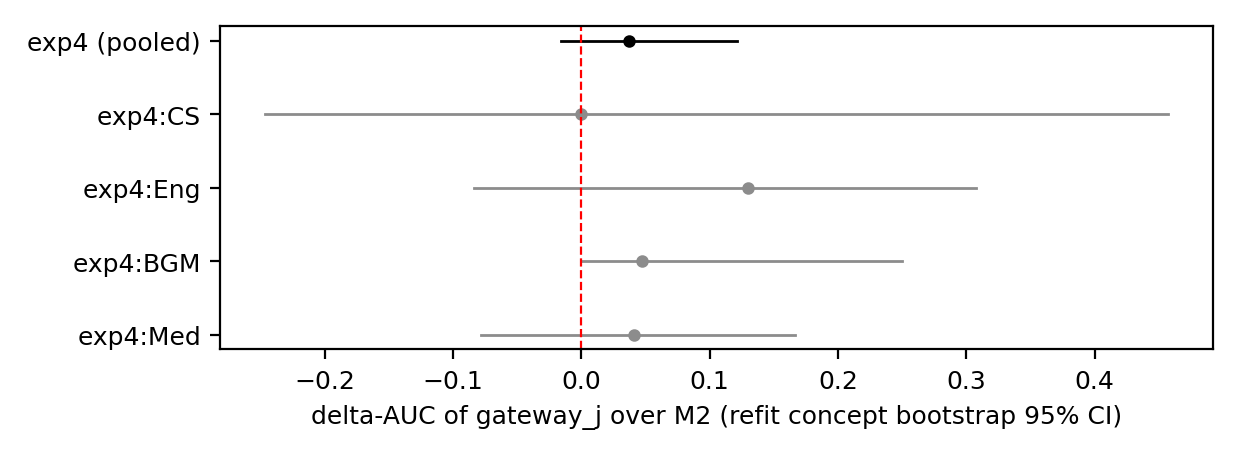

figures/placebo_hist.png


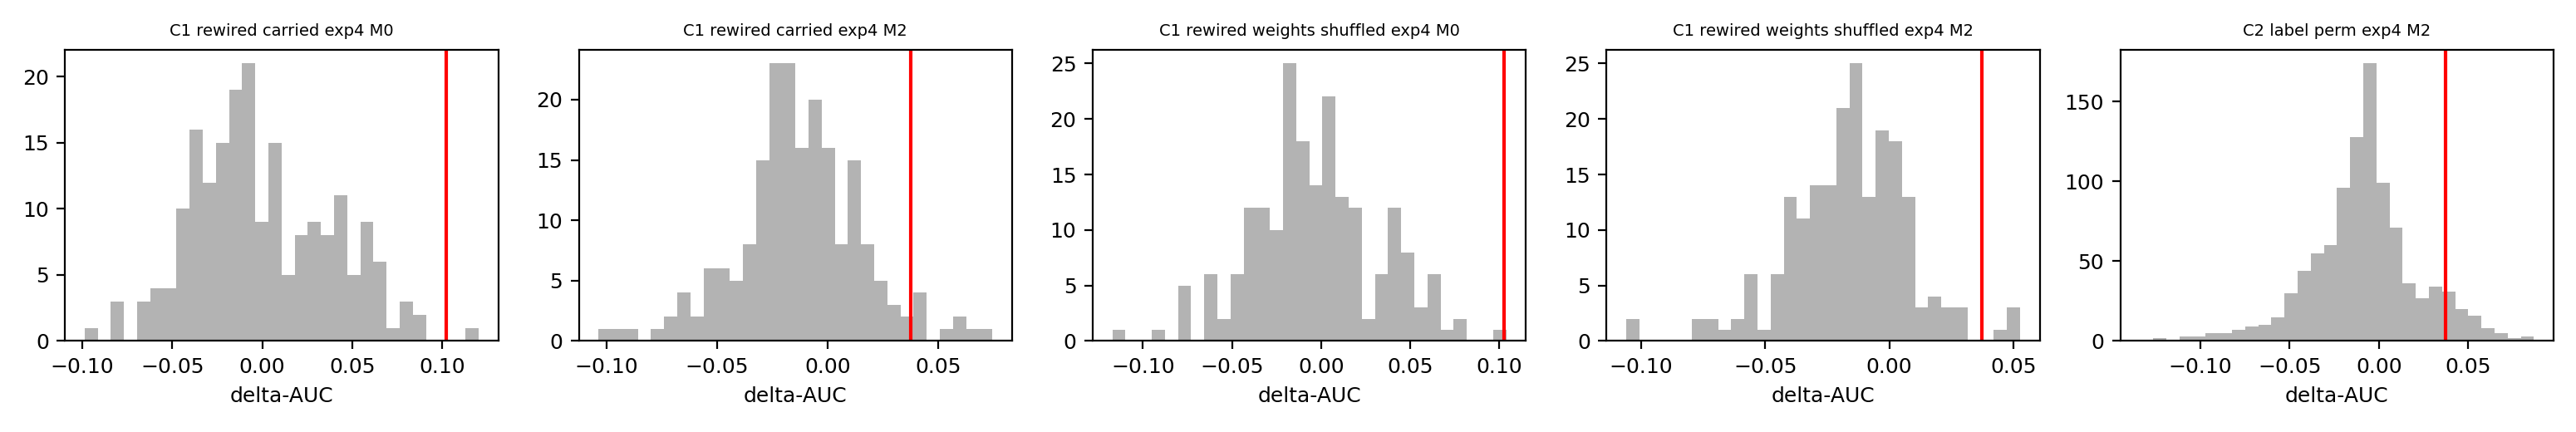

figures/stage2_field_intercepts.png


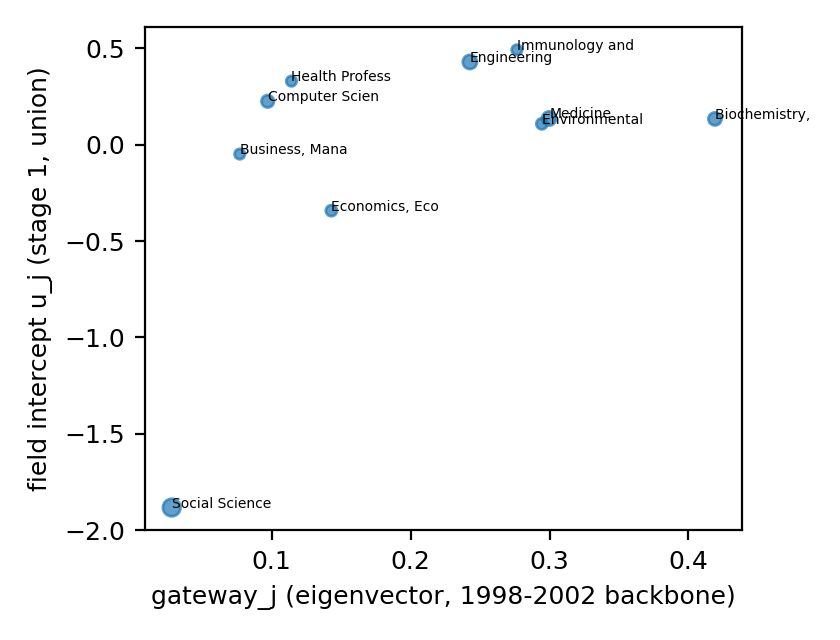

figures/mde_vs_n.png


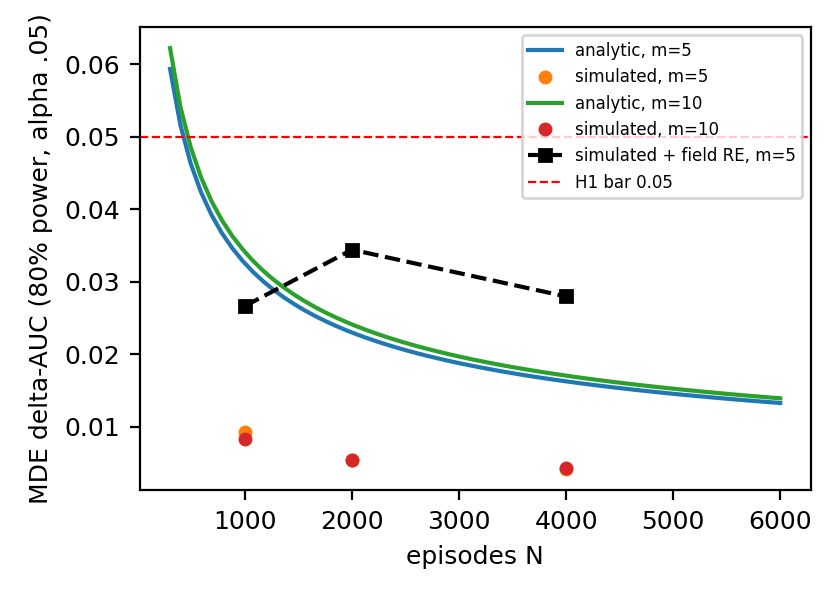

In [23]:
figs = figures(A, C, B2, E)
E.pop("_mde_fn", None)
B2.pop("_fe_union", None)
logger.info(f"demo run finished in {time.time() - t0:.0f}s; figures: {figs}")
for f in figs:
    print(f)
    display(Image(filename=str(HERE / f), width=620))
if _EXEC is not None:  # notebook: release the spawn workers (the script simply exits here)
    _EXEC.shutdown()
    _EXEC = None

## Results: demo run vs. the full run
The point estimates on exp4 match the full run exactly, because they do not depend on the number of draws. The CIs
and placebo percentiles come from far fewer draws here, so they are noisier. The full-run columns come from
`full_eval_out.json`, bundled in `mini_demo_data.json`. The bottom table and the plot show the replication panels
that decide the verdict. The exp4 lead does not carry over to the union panel or to the new episodes.

One small difference is expected: the full run counts exp4 M2 as positive in 4/4 groups, but CS's per-group delta
there is 1.1e-16, which is floating-point noise around 0. With other library versions it can land at 0 and give 3/4.

exp4 Block A: demo n_boot=400 vs full run 2000
       spec  demo_delta       demo_ci95  full_delta       full_ci95
         M0      0.1025  [0.021, 0.201]      0.1025  [0.025, 0.197]
         M1      0.0740 [-0.002, 0.197]      0.0740 [-0.004, 0.187]
         M2      0.0375 [-0.016, 0.121]      0.0375  [-0.018, 0.13]
       M2+P      0.0330 [-0.023, 0.086]      0.0330 [-0.019, 0.085]
    P_alone     -0.0305 [-0.146, 0.108]     -0.0305  [-0.15, 0.106]
   M2+Ppool      0.0419 [-0.014, 0.129]      0.0419 [-0.017, 0.118]
Ppool_alone     -0.0610   [-0.14, 0.02]     -0.0610 [-0.137, 0.015]

                               quantity  demo (exp4)  full run
C2 label-perm, exp4 M2: real percentile      92.5000   92.5000
       C1 rewired (carried), exp4 M0: p       0.0100    0.0100
C1 discrimination: median rho (carried)       0.3221    0.3221
                  B2 exp4 stage-2 slope       4.9296    4.9296
                     B2 exp4 stage-2 R2       0.5010    0.5010
                         B2 ex

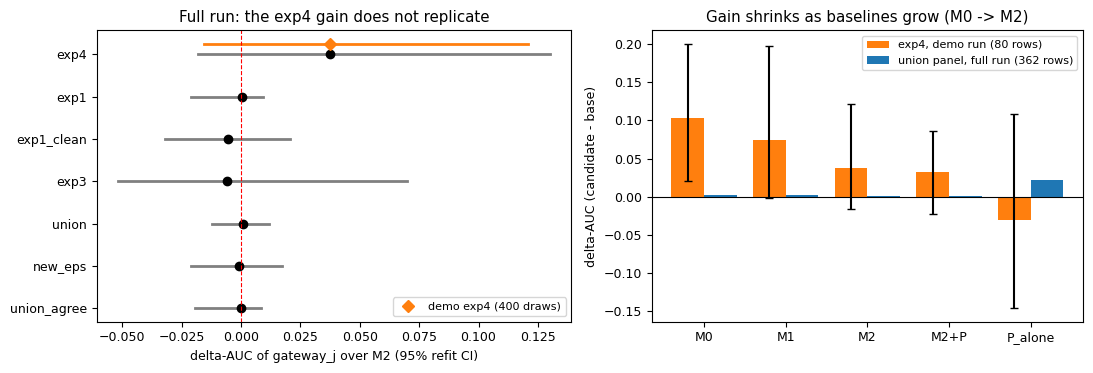

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt

ref = DEMO["full_run_reference"]
MA = ref["metrics_agg"]

# 1) exp4: demo vs full run, Block A specs
rows = []
for sp_ in ("M0", "M1", "M2", "M2+P", "P_alone", "M2+Ppool", "Ppool_alone"):
    s = A["exp4"]["specs"][sp_]
    tag = f"exp4_{sp_.replace('+', '_plus_')}"
    rows.append({"spec": sp_, "demo_delta": s["delta"],
                 "demo_ci95": np.round(s["refit_boot"].get("ci95", [np.nan] * 2), 3).tolist(),
                 "full_delta": MA.get(f"A_{tag}_delta_auc"),
                 "full_ci95": [round(MA.get(f"A_{tag}_ci95_lo", np.nan), 3), round(MA.get(f"A_{tag}_ci95_hi", np.nan), 3)]})
print(f"exp4 Block A: demo n_boot={A['exp4']['n_boot']} vs full run {ref['n_boot_full_run']['exp4']}")
print(pd.DataFrame(rows).round(4).to_string(index=False))

# 2) placebos + B2 + E: demo vs full run
cmp_ = [("C2 label-perm, exp4 M2: real percentile", C["C2_label_perm_exp4_M2"]["real_percentile"],
         MA.get("C2_label_perm_exp4_M2_real_percentile")),
        ("C1 rewired (carried), exp4 M0: p", C["C1_rewired_carried_exp4_M0"]["p_empirical"],
         MA.get("C1_rewired_carried_exp4_M0_p")),
        ("C1 discrimination: median rho (carried)", C["C1_discrimination_carried"]["median_spearman_real_vs_rewired"],
         MA.get("C1_discrimination_carried_median_rho")),
        ("B2 exp4 stage-2 slope", B2["exp4"]["stage2_gateway"]["slope"], MA.get("B2_exp4_stage2_gateway_slope")),
        ("B2 exp4 stage-2 R2", B2["exp4"]["stage2_gateway"]["R2"], MA.get("B2_exp4_stage2_gateway_R2")),
        ("B2 exp4 perm p", B2["exp4"]["stage2_gateway"]["perm_p_two_sided"], MA.get("B2_exp4_stage2_gateway_perm_p_two_sided")),
        ("F5 gateway_j (over M0) refit ci95 lo", F["F5_exp4_field_level"]["rows"]["gateway_j"]["new_ci95_refit"][0],
         ref["F5_full_run_rows"]["gateway_j"]["new_ci95_refit"][0]),
        ("F5 all_four_available refit ci95 lo", F["F5_exp4_field_level"]["rows"]["all_four_available"]["new_ci95_refit"][0],
         ref["F5_full_run_rows"]["all_four_available"]["new_ci95_refit"][0]),
        ("E rho_c (demo: exp4, full: union)", rho_c, MA.get("E_rho_c"))]
print()
print(pd.DataFrame(cmp_, columns=["quantity", "demo (exp4)", "full run"]).round(4).to_string(index=False))

# 3) the replication panels (full run only) and the verdict
hd = ref["summary"]["headline"]
tab = pd.DataFrame({ds: {"delta_over_M2": v["delta"], "ci95_lo": v["ci95"][0], "ci95_hi": v["ci95"][1],
                         "groups_positive": v["n_groups_positive"]} for ds, v in hd.items()}).T
print()
print("Full-run delta-AUC of gateway_j over M2, by panel:")
print(tab.round(4).to_string())
print("\nFull-run verdict:", ref["summary"]["verdict"])
print({k: v for k, v in ref["summary"]["conditions"].items()})

# plot: exp4 M0 lead vs M2 across panels (full run) with the demo's exp4 estimates overlaid
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.1, 1]})
order = ["exp4", "exp1", "exp1_clean", "exp3", "union", "new_eps", "union_agree"]
y = np.arange(len(order))[::-1]
for yy, ds in zip(y, order):
    v = hd[ds]
    axs[0].plot(v["ci95"], [yy, yy], color="0.5", lw=2)
    axs[0].plot(v["delta"], yy, "o", color="k")
dm = A["exp4"]["specs"]["M2"]
axs[0].plot(dm["refit_boot"]["ci95"], [y[0] + 0.25] * 2, color="tab:orange", lw=2)
axs[0].plot(dm["delta"], y[0] + 0.25, "D", color="tab:orange", label=f"demo exp4 ({A['exp4']['n_boot']} draws)")
axs[0].axvline(0, color="r", ls="--", lw=0.8)
axs[0].set_yticks(y, order)
axs[0].set_xlabel("delta-AUC of gateway_j over M2 (95% refit CI)")
axs[0].set_title("Full run: the exp4 gain does not replicate")
axs[0].legend(fontsize=8, loc="lower right")

specs_show = ["M0", "M1", "M2", "M2+P", "P_alone"]
xx = np.arange(len(specs_show))
dem = [A["exp4"]["specs"][s]["delta"] for s in specs_show]
err = np.array([[A["exp4"]["specs"][s]["delta"] - A["exp4"]["specs"][s]["refit_boot"]["ci95"][0],
                 A["exp4"]["specs"][s]["refit_boot"]["ci95"][1] - A["exp4"]["specs"][s]["delta"]] for s in specs_show]).T
uni = [MA.get(f"A_union_{s.replace('+', '_plus_')}_delta_auc") for s in specs_show]
axs[1].bar(xx - 0.2, dem, 0.4, yerr=err, capsize=3, color="tab:orange", label="exp4, demo run (80 rows)")
axs[1].bar(xx + 0.2, uni, 0.4, color="tab:blue", label="union panel, full run (362 rows)")
axs[1].axhline(0, color="k", lw=0.8)
axs[1].set_xticks(xx, specs_show)
axs[1].set_ylabel("delta-AUC (candidate - base)")
axs[1].set_title("Gain shrinks as baselines grow (M0 -> M2)")
axs[1].legend(fontsize=8)
plt.tight_layout()
plt.show()